# 🌫️ UCI Air Quality Dataset
## Notebook 1: Data Cleaning & Preprocessing

**Dataset**: UCI Air Quality — sensor kualitas udara per jam, Italia, Mar 2004 – Feb 2005  
**Tujuan**: Membersihkan data mentah agar siap digunakan untuk EDA dan Machine Learning

---
### 🗺️ Alur Notebook
```
1. Install & Import Libraries
2. Download & Load Dataset
3. Eksplorasi Awal
4. Fix Masalah Struktural (drop kolom kosong, rename)
5. Parse DateTime
6. Handle Missing Values (-200)
7. Deteksi & Atasi Outlier
8. Feature Engineering & Save
```

## 1. Install & Import Libraries

In [1]:
# Install library tambahan (missingno untuk visualisasi missing values)
!pip install missingno -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import urllib.request
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 110

print('✅ Semua library berhasil di-import!')


✅ Semua library berhasil di-import!


## 2. Download & Load Dataset

In [2]:
# Download langsung dari UCI ML Repository
print('📥 Mendownload UCI Air Quality Dataset...')

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip'
urllib.request.urlretrieve(url, 'AirQualityUCI.zip')

with zipfile.ZipFile('AirQualityUCI.zip', 'r') as z:
    z.extractall('.')
    print(f'📂 File yang diekstrak: {z.namelist()}')

# Dataset pakai semicolon (;) sebagai separator dan koma (,) sebagai desimal
# karena format data dari Italia (European number format)
df_raw = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',', encoding='utf-8')

print(f'\n✅ Dataset berhasil dimuat!')
print(f'📊 Shape: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom')
df_raw.head(3)

📥 Mendownload UCI Air Quality Dataset...
📂 File yang diekstrak: ['AirQualityUCI.csv', 'AirQualityUCI.xlsx']

✅ Dataset berhasil dimuat!
📊 Shape: 9471 baris × 17 kolom


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.60,1360.00,150.00,11.90,1046.00,166.00,1056.00,113.00,1692.00,1268.00,13.60,48.90,0.76,NaN,NaN
1,10/03/2004,19.00.00,2.00,1292.00,112.00,9.40,955.00,103.00,1174.00,92.00,1559.00,972.00,13.30,47.70,0.73,NaN,NaN
2,10/03/2004,20.00.00,2.20,1402.00,88.00,9.00,939.00,131.00,1140.00,114.00,1555.00,1074.00,11.90,54.00,0.75,NaN,NaN


## 3. Eksplorasi Awal

In [3]:
print('=' * 60)
print('📊 EKSPLORASI AWAL DATA')
print('=' * 60)

print(f'\n🔹 Shape          : {df_raw.shape}')
print(f'\n🔹 Nama kolom     :\n{list(df_raw.columns)}')
print(f'\n🔹 Tipe data      :\n{df_raw.dtypes}')
print(f'\n🔹 Jumlah NaN awal:\n{df_raw.isnull().sum()}')
print(f'\n🔹 Sample data:')
display(df_raw.head())

📊 EKSPLORASI AWAL DATA

🔹 Shape          : (9471, 17)

🔹 Nama kolom     :
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

🔹 Tipe data      :
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object

🔹 Jumlah NaN awal:
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.60,1360.00,150.00,11.90,1046.00,166.00,1056.00,113.00,1692.00,1268.00,13.60,48.90,0.76,NaN,NaN
1,10/03/2004,19.00.00,2.00,1292.00,112.00,9.40,955.00,103.00,1174.00,92.00,1559.00,972.00,13.30,47.70,0.73,NaN,NaN
2,10/03/2004,20.00.00,2.20,1402.00,88.00,9.00,939.00,131.00,1140.00,114.00,1555.00,1074.00,11.90,54.00,0.75,NaN,NaN
3,10/03/2004,21.00.00,2.20,1376.00,80.00,9.20,948.00,172.00,1092.00,122.00,1584.00,1203.00,11.00,60.00,0.79,NaN,NaN
4,10/03/2004,22.00.00,1.60,1272.00,51.00,6.50,836.00,131.00,1205.00,116.00,1490.00,1110.00,11.20,59.60,0.79,NaN,NaN


## 4. Fix Masalah Struktural

Dataset ini punya beberapa masalah bawaan:
- **2 kolom terakhir kosong** (artifact dari format CSV aslinya)
- **Beberapa baris kosong** di bagian bawah file
- **Nama kolom panjang dan ada karakter khusus** — perlu di-rename agar lebih mudah dipakai

In [4]:
df = df_raw.copy()

# 1. Drop 2 kolom terakhir yang kosong
print(f'Shape awal      : {df.shape}')
df = df.iloc[:, :-2]
print(f'Setelah drop 2 kolom kosong : {df.shape}')

# 2. Drop baris yang semuanya NaN
df = df.dropna(how='all')
print(f'Setelah drop baris kosong   : {df.shape}')

# 3. Rename kolom supaya lebih mudah dibaca
column_names = {
    'CO(GT)'      : 'CO_ref',
    'PT08.S1(CO)' : 'CO_sensor',
    'NMHC(GT)'    : 'NMHC_ref',
    'C6H6(GT)'    : 'Benzene_ref',
    'PT08.S2(NMHC)': 'NMHC_sensor',
    'NOx(GT)'     : 'NOx_ref',
    'PT08.S3(NOx)': 'NOx_sensor',
    'NO2(GT)'     : 'NO2_ref',
    'PT08.S4(NO2)': 'NO2_sensor',
    'PT08.S5(O3)' : 'O3_sensor',
    'T'           : 'Temperature',
    'RH'          : 'Humidity_rel',
    'AH'          : 'Humidity_abs'
}
df = df.rename(columns=column_names)

print(f'\n✅ Kolom setelah rename:')
print(list(df.columns))

Shape awal      : (9471, 17)
Setelah drop 2 kolom kosong : (9471, 15)
Setelah drop baris kosong   : (9357, 15)

✅ Kolom setelah rename:
['Date', 'Time', 'CO_ref', 'CO_sensor', 'NMHC_ref', 'Benzene_ref', 'NMHC_sensor', 'NOx_ref', 'NOx_sensor', 'NO2_ref', 'NO2_sensor', 'O3_sensor', 'Temperature', 'Humidity_rel', 'Humidity_abs']


## 5. Parse DateTime

Kolom `Date` dan `Time` masih terpisah dan formatnya tidak standar (`DD/MM/YYYY` dan `HH.MM.SS`).  
Kita gabungkan menjadi satu kolom `DateTime` lalu jadikan sebagai index.

In [5]:
# Gabungkan Date dan Time menjadi satu kolom DateTime
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)

# Cek parsing error
n_nat = df['DateTime'].isna().sum()
print(f'⚠️  DateTime parsing error  : {n_nat} baris')

# Drop kolom Date dan Time asli
df = df.drop(columns=['Date', 'Time'])

# Set DateTime sebagai index dan urutkan
df = df.set_index('DateTime').sort_index()

print(f'\n✅ DateTime parsed!')
print(f'📅 Rentang data : {df.index.min()}  →  {df.index.max()}')
print(f'⏱️  Total data   : {len(df)} jam')
df.head()

⚠️  DateTime parsing error  : 0 baris

✅ DateTime parsed!
📅 Rentang data : 2004-03-10 18:00:00  →  2005-04-04 14:00:00
⏱️  Total data   : 9357 jam


,CO_ref,CO_sensor,NMHC_ref,Benzene_ref,NMHC_sensor,NOx_ref,NOx_sensor,NO2_ref,NO2_sensor,O3_sensor,Temperature,Humidity_rel,Humidity_abs
DateTime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.60,1360.00,150.00,11.90,1046.00,166.00,1056.00,113.00,1692.00,1268.00,13.60,48.90,0.76
2004-03-10 19:00:00,2.00,1292.00,112.00,9.40,955.00,103.00,1174.00,92.00,1559.00,972.00,13.30,47.70,0.73
2004-03-10 20:00:00,2.20,1402.00,88.00,9.00,939.00,131.00,1140.00,114.00,1555.00,1074.00,11.90,54.00,0.75
2004-03-10 21:00:00,2.20,1376.00,80.00,9.20,948.00,172.00,1092.00,122.00,1584.00,1203.00,11.00,60.00,0.79
2004-03-10 22:00:00,1.60,1272.00,51.00,6.50,836.00,131.00,1205.00,116.00,1490.00,1110.00,11.20,59.60,0.79


## 6. Handle Missing Values (-200)

**Fakta penting**: Dalam dataset ini, nilai `-200` bukan data valid — itu adalah kode untuk **missing/sensor error**.  
Kita perlu menggantinya dengan `NaN`, lalu mengimputasi dengan metode yang sesuai untuk data time series.

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Cek berapa banyak nilai -200 per kolom
print('🔍 Jumlah nilai -200 (missing) per kolom:')
missing_200 = (df[numeric_cols] == -200).sum()
missing_pct  = (missing_200 / len(df) * 100).round(2)
missing_info = pd.DataFrame({'Jumlah -200': missing_200, '% dari total': missing_pct})
print(missing_info[missing_info['Jumlah -200'] > 0].to_string())

# Ganti -200 dengan NaN
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)
print(f'\n✅ Nilai -200 diganti dengan NaN')

🔍 Jumlah nilai -200 (missing) per kolom:
              Jumlah -200  % dari total
CO_ref               1683         17.99
CO_sensor             366          3.91
NMHC_ref             8443         90.23
Benzene_ref           366          3.91
NMHC_sensor           366          3.91
NOx_ref              1639         17.52
NOx_sensor            366          3.91
NO2_ref              1642         17.55
NO2_sensor            366          3.91
O3_sensor             366          3.91
Temperature           366          3.91
Humidity_rel          366          3.91
Humidity_abs          366          3.91

✅ Nilai -200 diganti dengan NaN


📊 Visualisasi ketersediaan data per kolom:


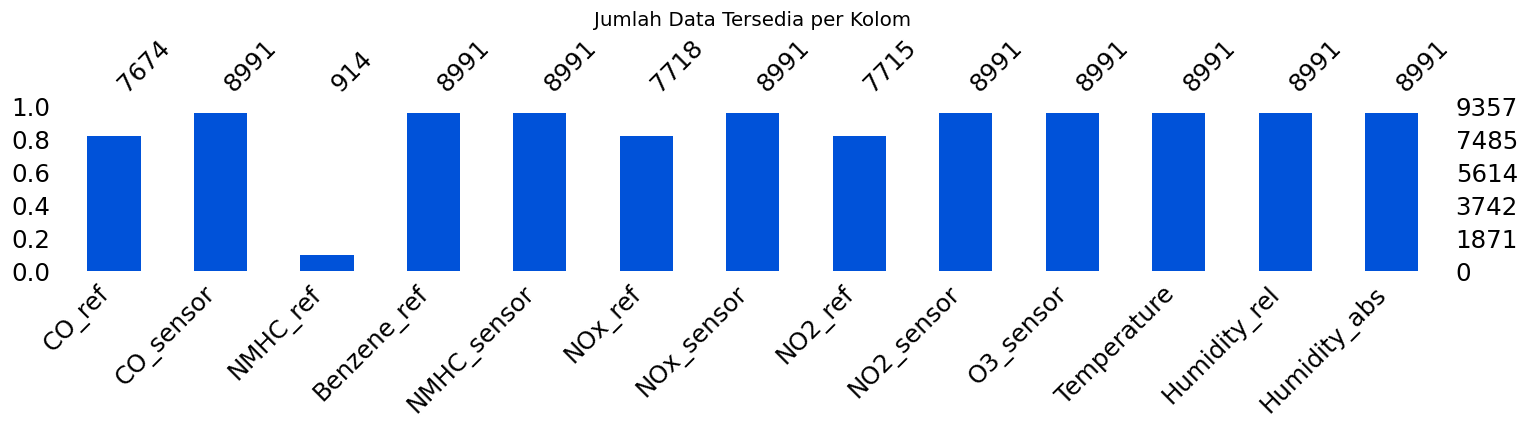


⚠️  NMHC_ref missing: 90.2% — kolom ini akan di-drop
✅ Setelah imputasi — sisa NaN: 0


In [7]:
# Visualisasi missing values
print('📊 Visualisasi ketersediaan data per kolom:')
msno.bar(df[numeric_cols], color='#0052D9', figsize=(14, 4))
plt.title('Jumlah Data Tersedia per Kolom', fontsize=13)
plt.tight_layout()
plt.show()

# NMHC_ref hampir semua missing (>90%) -> lebih baik di-drop
nmhc_pct = df['NMHC_ref'].isna().mean() * 100
print(f'\n⚠️  NMHC_ref missing: {nmhc_pct:.1f}% — kolom ini akan di-drop')
df = df.drop(columns=['NMHC_ref'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Imputasi: interpolasi time series (lebih tepat dari mean untuk data per jam)
# limit=24 artinya maksimal mengisi gap 24 jam berturut-turut
df[numeric_cols] = df[numeric_cols].interpolate(method='time', limit=24)

# Sisa NaN (jika gap > 24 jam) -> ffill lalu bfill
df[numeric_cols] = df[numeric_cols].ffill().bfill()

remaining = df[numeric_cols].isnull().sum().sum()
print(f'✅ Setelah imputasi — sisa NaN: {remaining}')

## 7. Deteksi & Atasi Outlier

Kita pakai metode **IQR (Interquartile Range)** untuk mendeteksi outlier.  
Strategi: **Winsorization** (cap ke batas IQR), bukan menghapus — lebih aman untuk data time series.

In [8]:
print('📊 Deteksi Outlier — Metode IQR\n')

records = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    records.append({
        'Kolom'          : col,
        'Lower Bound'    : round(lower, 2),
        'Upper Bound'    : round(upper, 2),
        'Jumlah Outlier' : n_out,
        'Persentase (%)'  : round(n_out / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(records)
print(outlier_df.to_string(index=False))

📊 Deteksi Outlier — Metode IQR

       Kolom  Lower Bound  Upper Bound  Jumlah Outlier  Persentase (%)
      CO_ref        -1.45         5.35             308            3.29
   CO_sensor       488.00      1688.00             105            1.12
 Benzene_ref        -9.75        28.25             251            2.68
 NMHC_sensor       163.00      1691.00              66            0.71
     NOx_ref      -258.72       686.71             403            4.31
  NOx_sensor       184.00      1440.00             238            2.54
     NO2_ref       -15.50       228.50             152            1.62
  NO2_sensor       560.50      2340.50              98            1.05
   O3_sensor      -103.00      2121.00              73            0.78
 Temperature        -6.70        42.90               4            0.04
Humidity_rel        -4.30       102.10               0            0.00
Humidity_abs        -0.14         2.18               3            0.03


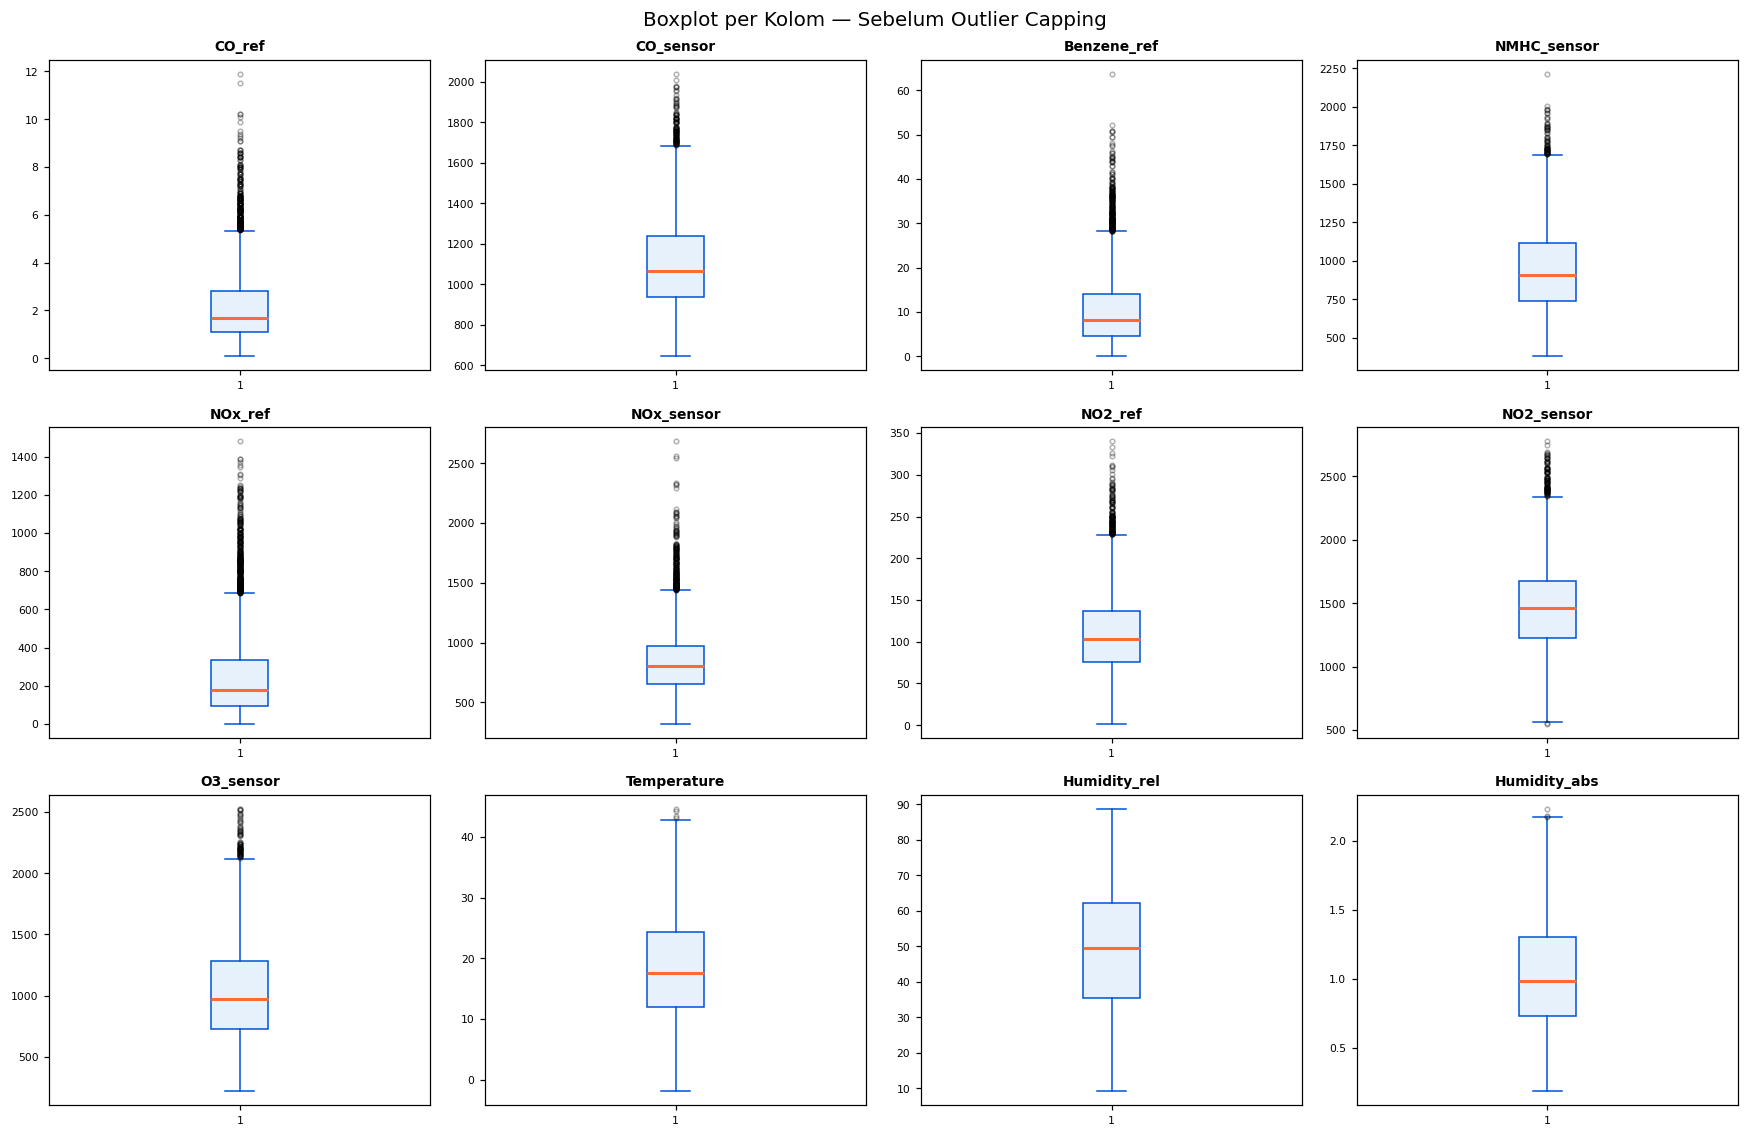

✅ Outlier di-cap dengan IQR Winsorization (data tidak dihapus)


In [9]:
# Visualisasi boxplot
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#E6F1FB', color='#0052D9'),
        medianprops=dict(color='#FF6B35', linewidth=2),
        whiskerprops=dict(color='#0052D9'),
        capprops=dict(color='#0052D9'),
        flierprops=dict(marker='o', color='#FF6B35', alpha=0.3, markersize=3)
    )
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot per Kolom — Sebelum Outlier Capping', fontsize=13)
plt.tight_layout()
plt.show()

# Winsorization: clip nilai ke batas IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print('✅ Outlier di-cap dengan IQR Winsorization (data tidak dihapus)')

## 8. Feature Engineering & Save

Tambahkan fitur-fitur waktu yang berguna untuk analisis pola (EDA) dan modeling.

In [10]:
print('🔧 Feature Engineering — Fitur Waktu\n')

df['hour']        = df.index.hour
df['day']         = df.index.day
df['month']       = df.index.month
df['dayofweek']   = df.index.dayofweek   # 0=Senin, 6=Minggu
df['is_weekend']  = df['dayofweek'].isin([5, 6]).astype(int)

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3 : 'Spring', 4: 'Spring', 5: 'Spring',
    6 : 'Summer', 7: 'Summer', 8: 'Summer',
    9 : 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# Jam sibuk pagi (7-9) dan sore (17-19)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

def time_of_day(h):
    if   5  <= h < 12: return 'Pagi'
    elif 12 <= h < 17: return 'Siang'
    elif 17 <= h < 21: return 'Sore'
    else:               return 'Malam'

df['time_of_day'] = df['hour'].apply(time_of_day)

print('✅ Fitur baru yang ditambahkan:')
print('   hour, day, month, dayofweek, is_weekend, season, is_rush_hour, time_of_day')
print(f'\n📋 Preview:')
display(df[['CO_ref', 'Temperature', 'hour', 'is_rush_hour', 'time_of_day', 'season']].head(8))

🔧 Feature Engineering — Fitur Waktu

✅ Fitur baru yang ditambahkan:
   hour, day, month, dayofweek, is_weekend, season, is_rush_hour, time_of_day

📋 Preview:


,CO_ref,Temperature,hour,is_rush_hour,time_of_day,season
DateTime,,,,,,
2004-03-10 18:00:00,2.60,13.60,18,1,Sore,Spring
2004-03-10 19:00:00,2.00,13.30,19,1,Sore,Spring
2004-03-10 20:00:00,2.20,11.90,20,0,Sore,Spring
2004-03-10 21:00:00,2.20,11.00,21,0,Malam,Spring
2004-03-10 22:00:00,1.60,11.20,22,0,Malam,Spring
2004-03-10 23:00:00,1.20,11.20,23,0,Malam,Spring
2004-03-11 00:00:00,1.20,11.30,0,0,Malam,Spring
2004-03-11 01:00:00,1.00,10.70,1,0,Malam,Spring


In [11]:
print('=' * 60)
print('✅ RINGKASAN DATASET FINAL')
print('=' * 60)
print(f'\n🔹 Shape           : {df.shape}')
print(f'🔹 Rentang tanggal : {df.index.min()} → {df.index.max()}')
print(f'🔹 Sisa NaN        : {df.isnull().sum().sum()}')
print(f'\n📊 Statistik Deskriptif:')
display(df.describe().round(2))

# Simpan dataset bersih
df.to_csv('air_quality_cleaned.csv')
print(f'\n💾 Dataset bersih disimpan: air_quality_cleaned.csv')
print(f'📦 {df.shape[0]} baris × {df.shape[1]} kolom')
print('\n🎉 Data Cleaning selesai! Lanjut → Notebook 2: EDA')

✅ RINGKASAN DATASET FINAL

🔹 Shape           : (9357, 20)
🔹 Rentang tanggal : 2004-03-10 18:00:00 → 2005-04-04 14:00:00
🔹 Sisa NaN        : 0

📊 Statistik Deskriptif:


,CO_ref,CO_sensor,Benzene_ref,NMHC_sensor,NOx_ref,NOx_sensor,NO2_ref,NO2_sensor,O3_sensor,Temperature,Humidity_rel,Humidity_abs,hour,day,month,dayofweek,is_weekend,is_rush_hour
count,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00
mean,2.07,1101.58,10.02,941.36,233.13,827.76,109.01,1451.25,1030.22,18.26,49.07,1.02,11.50,15.88,6.31,3.01,0.29,0.25
std,1.32,214.67,7.01,265.91,178.13,237.05,45.22,340.10,400.44,8.77,17.21,0.40,6.92,8.81,3.44,2.00,0.45,0.43
min,0.10,647.00,0.10,383.00,2.00,322.00,2.00,560.50,221.00,-1.90,9.20,0.18,0.00,1.00,1.00,0.00,0.00,0.00
25%,1.10,938.00,4.50,736.00,95.82,655.00,76.00,1228.00,731.00,11.90,35.60,0.73,5.00,8.00,3.00,1.00,0.00,0.00
50%,1.70,1067.00,8.26,909.00,177.37,804.00,103.00,1460.00,970.00,17.60,49.60,0.99,11.00,16.00,6.00,3.00,0.00,0.00
75%,2.80,1238.00,14.00,1118.00,332.17,969.00,137.00,1673.00,1287.00,24.30,62.20,1.31,18.00,23.00,9.00,5.00,1.00,0.00
max,5.35,1688.00,28.25,1691.00,686.71,1440.00,228.50,2340.50,2121.00,42.90,88.70,2.18,23.00,31.00,12.00,6.00,1.00,1.00



💾 Dataset bersih disimpan: air_quality_cleaned.csv
📦 9357 baris × 20 kolom

🎉 Data Cleaning selesai! Lanjut → Notebook 2: EDA


---
# 📊 Part 2: Exploratory Data Analysis (EDA) & Visualisasi
> Lanjutan dari Part 1 — pastikan semua cell di atas sudah dijalankan terlebih dahulu.

## 1. Import & Load Data

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.dpi'      : 110,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'axes.prop_cycle' : plt.cycler(color=[
        '#0052D9','#FF6B35','#00C4E8','#1DB954','#FF3B6B','#9B59B6','#F39C12'
    ])
})

BLUE   = '#0052D9'
ORANGE = '#FF6B35'
CYAN   = '#00C4E8'
RED    = '#FF3B6B'
GREEN  = '#1DB954'

# Load data hasil Notebook 1
df = pd.read_csv('air_quality_cleaned.csv', index_col='DateTime', parse_dates=True)

print(f'✅ Data dimuat: {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'📅 Rentang: {df.index.min().date()} → {df.index.max().date()}')
df.head(3)

✅ Data dimuat: 9357 baris × 20 kolom
📅 Rentang: 2004-03-10 → 2005-04-04


,CO_ref,CO_sensor,Benzene_ref,NMHC_sensor,NOx_ref,NOx_sensor,NO2_ref,NO2_sensor,O3_sensor,Temperature,Humidity_rel,Humidity_abs,hour,day,month,dayofweek,is_weekend,season,is_rush_hour,time_of_day
DateTime,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.60,1360.00,11.90,1046.00,166.00,1056.00,113.00,1692.00,1268.00,13.60,48.90,0.76,18,10,3,2,0,Spring,1,Sore
2004-03-10 19:00:00,2.00,1292.00,9.40,955.00,103.00,1174.00,92.00,1559.00,972.00,13.30,47.70,0.73,19,10,3,2,0,Spring,1,Sore
2004-03-10 20:00:00,2.20,1402.00,9.00,939.00,131.00,1140.00,114.00,1555.00,1074.00,11.90,54.00,0.75,20,10,3,2,0,Spring,0,Sore


## 2. Overview Statistik

In [13]:
# Kolom polutan utama yang akan difokuskan
pollutants    = ['CO_ref', 'Benzene_ref', 'NOx_ref', 'NO2_ref']
sensors       = ['CO_sensor', 'NMHC_sensor', 'NOx_sensor', 'NO2_sensor', 'O3_sensor']
weather_cols  = ['Temperature', 'Humidity_rel', 'Humidity_abs']
time_features = ['hour', 'dayofweek', 'month', 'is_weekend', 'is_rush_hour']

print('=' * 65)
print('📊 STATISTIK DESKRIPTIF — POLUTAN UTAMA')
print('=' * 65)
display(df[pollutants + weather_cols].describe().round(2))

print('\n📋 Catatan Satuan:')
print('  CO_ref      → mg/m³  (karbon monoksida)')
print('  Benzene_ref → µg/m³  (benzena)')
print('  NOx_ref     → ppb    (nitrogen oksida)')
print('  NO2_ref     → µg/m³  (nitrogen dioksida)')
print('  Temperature → °C')
print('  Humidity_rel→ %')

📊 STATISTIK DESKRIPTIF — POLUTAN UTAMA


,CO_ref,Benzene_ref,NOx_ref,NO2_ref,Temperature,Humidity_rel,Humidity_abs
count,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00
mean,2.07,10.02,233.13,109.01,18.26,49.07,1.02
std,1.32,7.01,178.13,45.22,8.77,17.21,0.40
min,0.10,0.10,2.00,2.00,-1.90,9.20,0.18
25%,1.10,4.50,95.82,76.00,11.90,35.60,0.73
50%,1.70,8.26,177.37,103.00,17.60,49.60,0.99
75%,2.80,14.00,332.17,137.00,24.30,62.20,1.31
max,5.35,28.25,686.71,228.50,42.90,88.70,2.18



📋 Catatan Satuan:
  CO_ref      → mg/m³  (karbon monoksida)
  Benzene_ref → µg/m³  (benzena)
  NOx_ref     → ppb    (nitrogen oksida)
  NO2_ref     → µg/m³  (nitrogen dioksida)
  Temperature → °C
  Humidity_rel→ %


## 3. Distribusi Variabel (Histogram + KDE)

Memahami bentuk distribusi tiap polutan — apakah normal, skewed, atau bimodal?

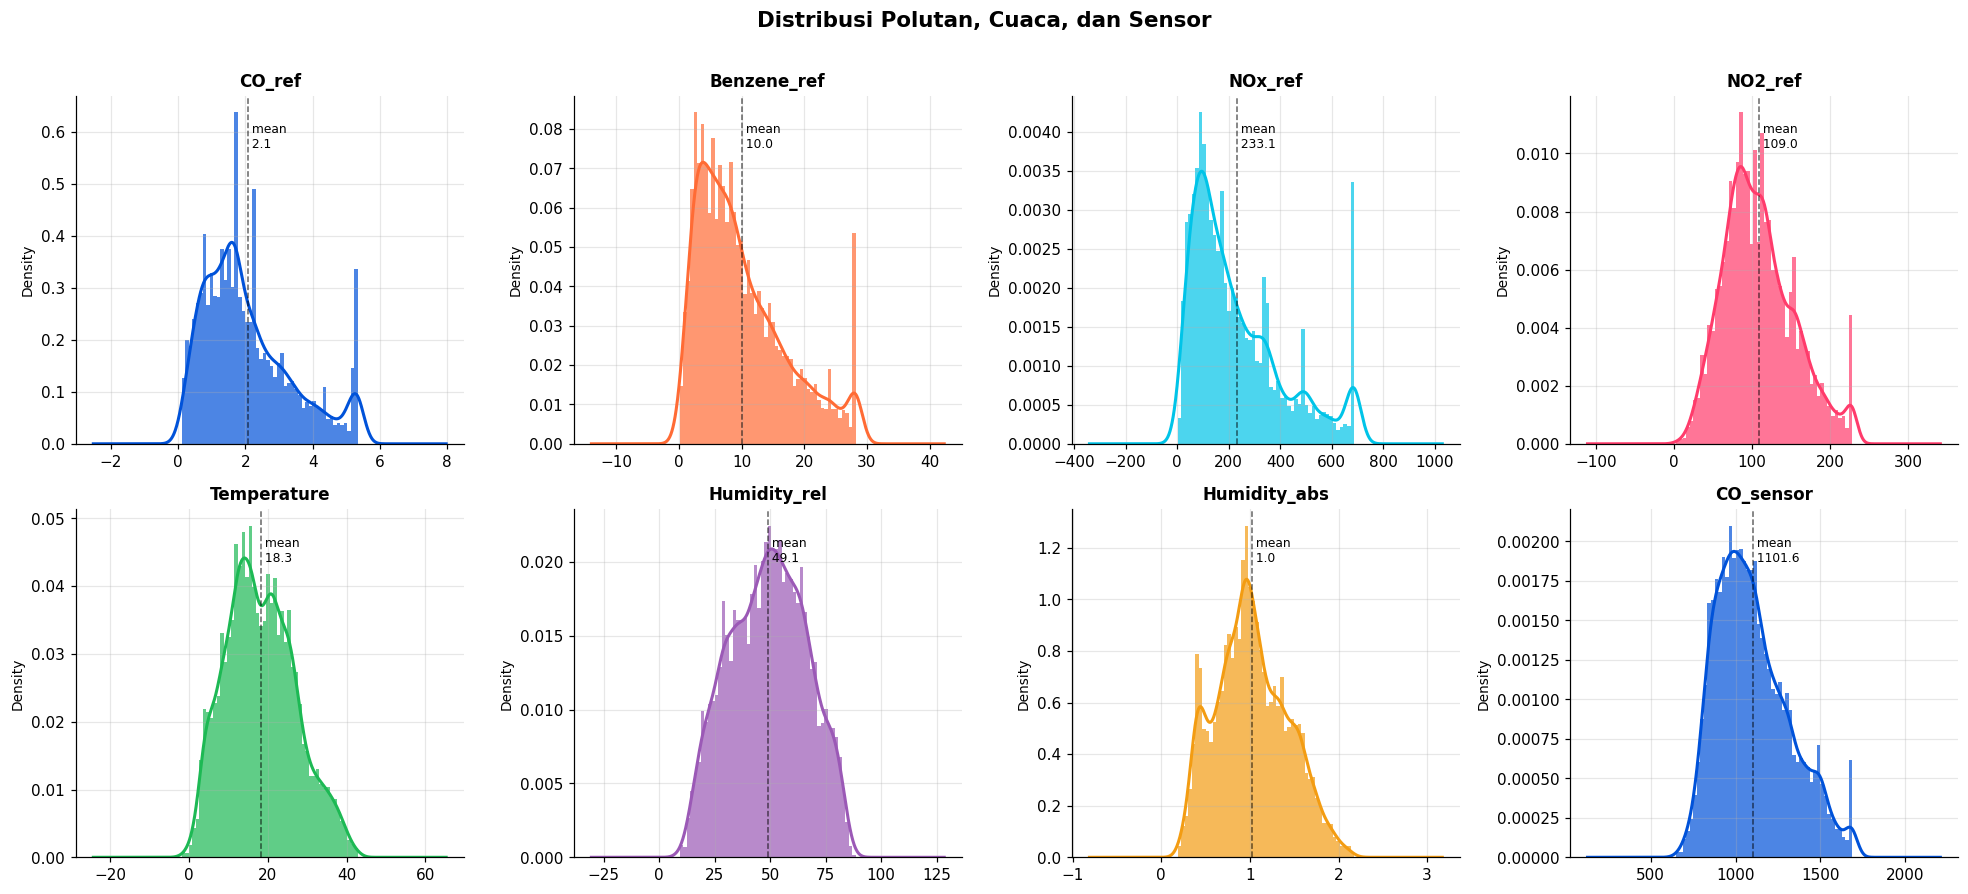

💡 Insight:
  • CO_ref skewed kanan → ada jam-jam dengan lonjakan CO ekstrem
  • Benzene & NOx juga right-skewed — polusi kendaraan biasanya spike pendek
  • Temperature mendekati normal — konsisten dengan data per jam sepanjang tahun


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

all_cols = pollutants + weather_cols + ['CO_sensor']
colors   = [BLUE, ORANGE, CYAN, RED, GREEN, '#9B59B6', '#F39C12', BLUE]

for i, (col, c) in enumerate(zip(all_cols, colors)):
    axes[i].hist(df[col].dropna(), bins=50, color=c, alpha=0.7, density=True, edgecolor='none')
    df[col].dropna().plot.kde(ax=axes[i], color=c, linewidth=2)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density', fontsize=9)
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='black', linestyle='--', linewidth=1, alpha=0.6)
    axes[i].text(mean_val, axes[i].get_ylim()[1]*0.85,
                 f' mean\n {mean_val:.1f}', fontsize=8, color='black')

plt.suptitle('Distribusi Polutan, Cuaca, dan Sensor', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Insight:')
print(f'  • CO_ref skewed kanan → ada jam-jam dengan lonjakan CO ekstrem')
print(f'  • Benzene & NOx juga right-skewed — polusi kendaraan biasanya spike pendek')
print(f'  • Temperature mendekati normal — konsisten dengan data per jam sepanjang tahun')

## 4. Tren Time Series

Melihat perubahan level polutan dari waktu ke waktu (Mar 2004 – Feb 2005).

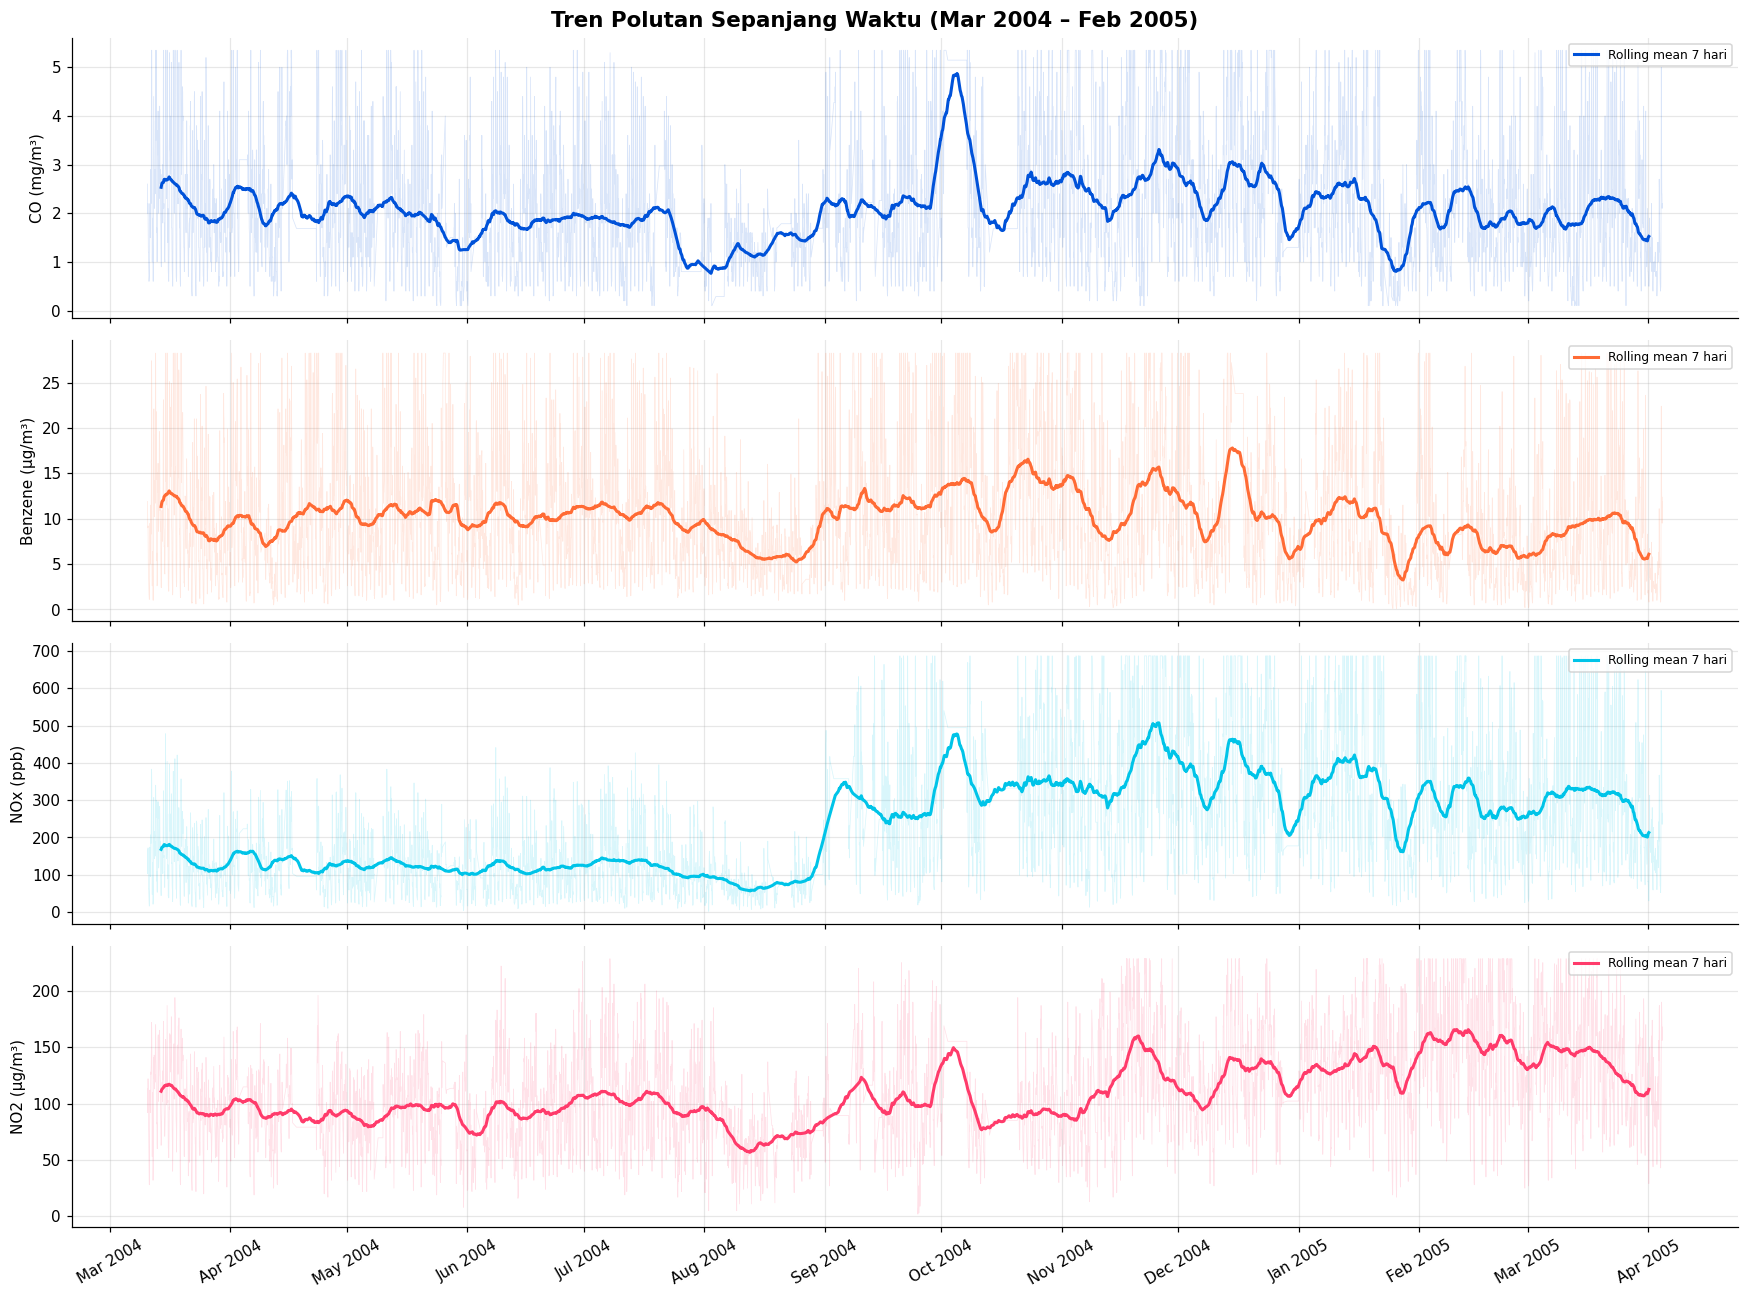

💡 Insight:
  • Perhatikan apakah ada lonjakan di musim dingin (Des-Feb) — biasanya lebih tinggi
  • Garis tebal = tren 7-hari, lebih mudah dibaca daripada data mentah per jam


In [15]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

ts_data = [
    ('CO_ref',      'CO (mg/m³)',         BLUE),
    ('Benzene_ref', 'Benzene (µg/m³)',     ORANGE),
    ('NOx_ref',     'NOx (ppb)',           CYAN),
    ('NO2_ref',     'NO2 (µg/m³)',         RED),
]

for ax, (col, label, c) in zip(axes, ts_data):
    # Raw data (transparan)
    ax.plot(df.index, df[col], color=c, alpha=0.15, linewidth=0.5)
    # Rolling mean 7 hari (168 jam) untuk tren
    rolling = df[col].rolling(window=168, center=True).mean()
    ax.plot(df.index, rolling, color=c, linewidth=2, label='Rolling mean 7 hari')
    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.suptitle('Tren Polutan Sepanjang Waktu (Mar 2004 – Feb 2005)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Insight:')
print('  • Perhatikan apakah ada lonjakan di musim dingin (Des-Feb) — biasanya lebih tinggi')
print('  • Garis tebal = tren 7-hari, lebih mudah dibaca daripada data mentah per jam')

## 5. Pola Per Jam — Rush Hour Analysis

**Pertanyaan utama: Jam berapa udara paling berbahaya dalam sehari?**

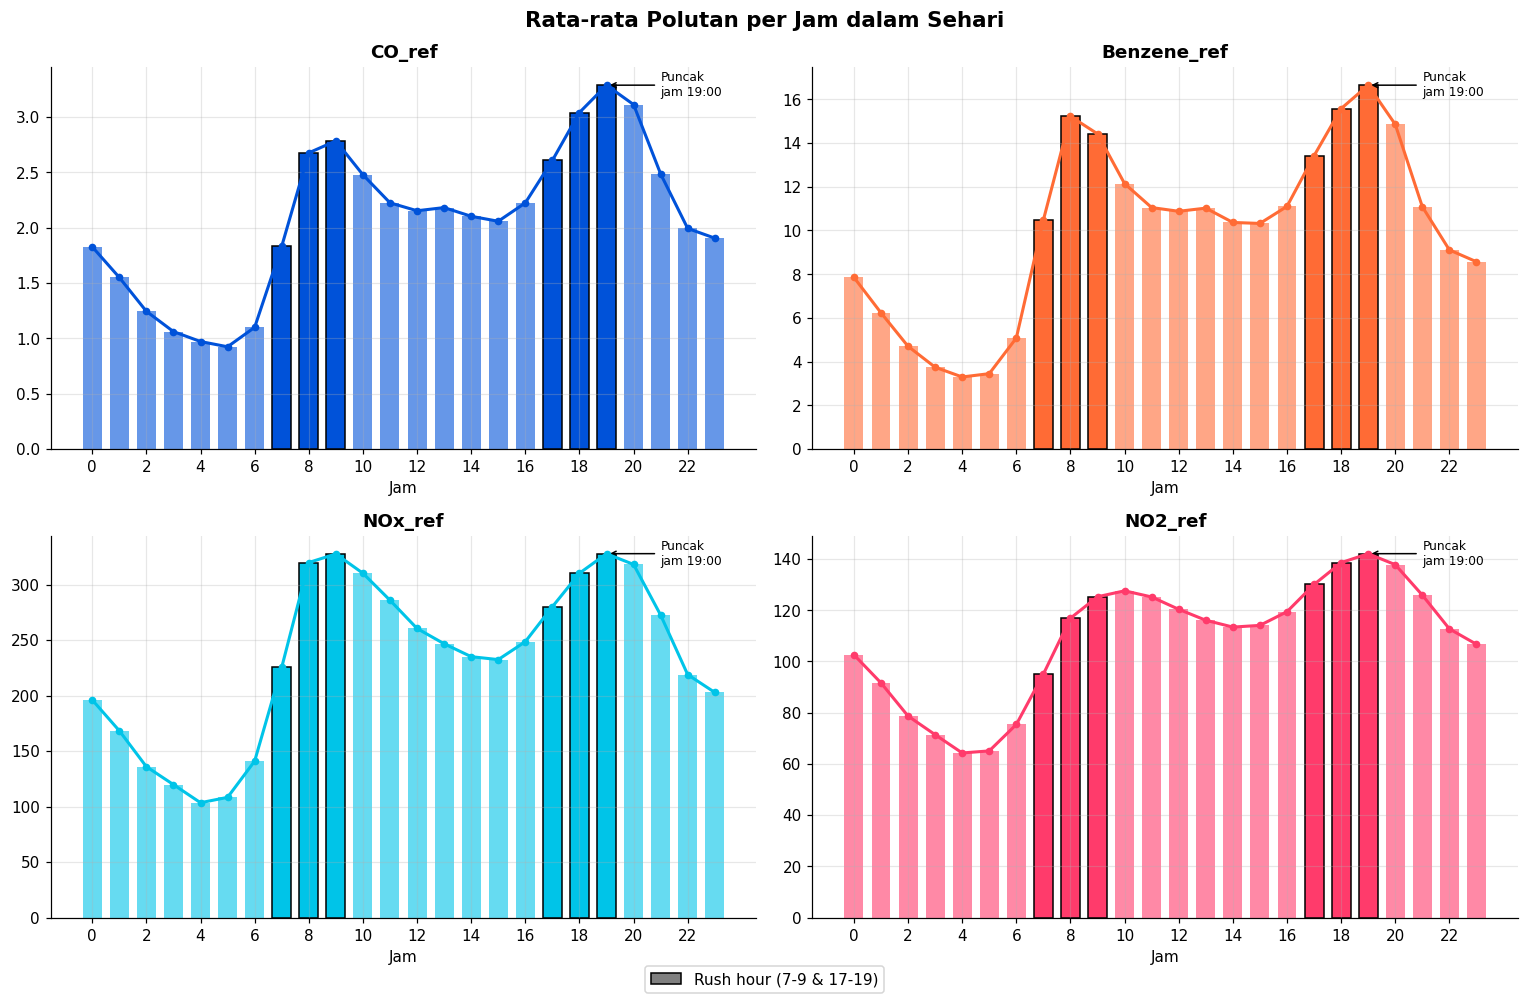


🕐 Jam puncak tiap polutan:
  CO_ref          → jam 19:00
  Benzene_ref     → jam 19:00
  NOx_ref         → jam 19:00
  NO2_ref         → jam 19:00


In [16]:
hourly_avg = df.groupby('hour')[pollutants].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

colors_list = [BLUE, ORANGE, CYAN, RED]
rush_hours  = [7, 8, 9, 17, 18, 19]

for i, (col, c) in enumerate(zip(pollutants, colors_list)):
    ax = axes[i]
    bars = ax.bar(hourly_avg.index, hourly_avg[col], color=c, alpha=0.6, width=0.7)
    # Highlight rush hours
    for j, (bar, h) in enumerate(zip(bars, hourly_avg.index)):
        if h in rush_hours:
            bar.set_alpha(1.0)
            bar.set_edgecolor('black')
            bar.set_linewidth(1)
    ax.plot(hourly_avg.index, hourly_avg[col], color=c, linewidth=2, marker='o',
            markersize=4, zorder=5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Jam', fontsize=10)
    ax.set_xticks(range(0, 24, 2))
    peak_hour = hourly_avg[col].idxmax()
    peak_val  = hourly_avg[col].max()
    ax.annotate(f'Puncak\njam {peak_hour}:00',
                xy=(peak_hour, peak_val),
                xytext=(peak_hour + 2, peak_val * 0.97),
                fontsize=8, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1))

# Tambah legenda rush hour
from matplotlib.patches import Patch
legend_el = [Patch(facecolor='gray', edgecolor='black', label='Rush hour (7-9 & 17-19)')]
fig.legend(handles=legend_el, loc='lower center', ncol=1, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Rata-rata Polutan per Jam dalam Sehari',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabel puncak
print('\n🕐 Jam puncak tiap polutan:')
for col in pollutants:
    peak_h = hourly_avg[col].idxmax()
    print(f'  {col:<15} → jam {peak_h:02d}:00')

## 6. Pola Per Hari dalam Seminggu

Apakah weekend lebih bersih dari hari kerja?

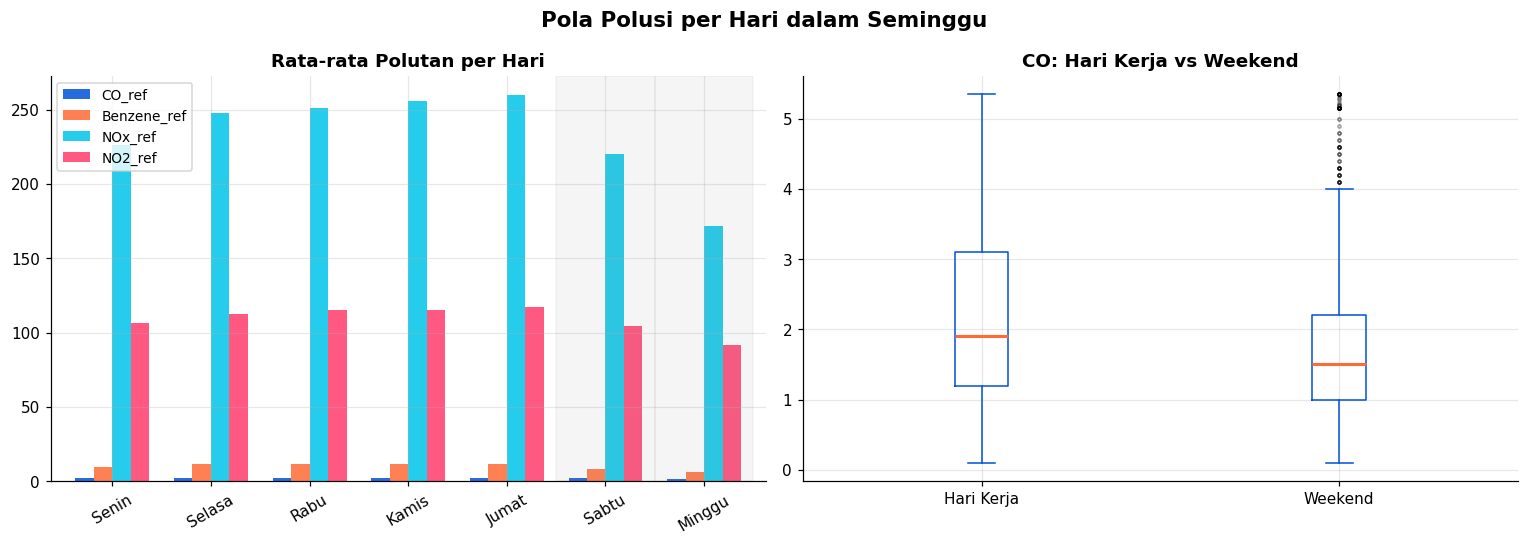


📊 Rata-rata CO per kategori hari:
day_type
Hari Kerja   2.22
Weekend      1.72

💡 Hari kerja rata-rata lebih tinggi 0.499 mg/m³ dibanding weekend


In [17]:
day_labels = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
weekly_avg = df.groupby('dayofweek')[pollutants].mean()
weekly_avg.index = day_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Grouped bar untuk semua polutan
weekly_avg.plot(kind='bar', ax=axes[0], width=0.75,
                color=[BLUE, ORANGE, CYAN, RED], alpha=0.85, edgecolor='none')
axes[0].set_title('Rata-rata Polutan per Hari', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)
# Shade weekend
for x in [5, 6]:
    axes[0].axvspan(x - 0.5, x + 0.5, alpha=0.08, color='gray', label='_')

# Plot 2: Weekday vs Weekend boxplot (CO_ref)
df['day_type'] = df['is_weekend'].map({0: 'Hari Kerja', 1: 'Weekend'})
df.boxplot(column='CO_ref', by='day_type', ax=axes[1],
           boxprops=dict(color=BLUE),
           medianprops=dict(color=ORANGE, linewidth=2),
           whiskerprops=dict(color=BLUE),
           capprops=dict(color=BLUE),
           flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_title('CO: Hari Kerja vs Weekend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
plt.suptitle('')

plt.suptitle('Pola Polusi per Hari dalam Seminggu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistik perbandingan
print('\n📊 Rata-rata CO per kategori hari:')
print(df.groupby('day_type')['CO_ref'].mean().round(3).to_string())
diff = (df[df['is_weekend']==0]['CO_ref'].mean() -
        df[df['is_weekend']==1]['CO_ref'].mean())
print(f'\n💡 Hari kerja rata-rata lebih tinggi {diff:.3f} mg/m³ dibanding weekend')

## 7. Analisis Musiman & Bulanan

Bagaimana kualitas udara berubah antar musim?

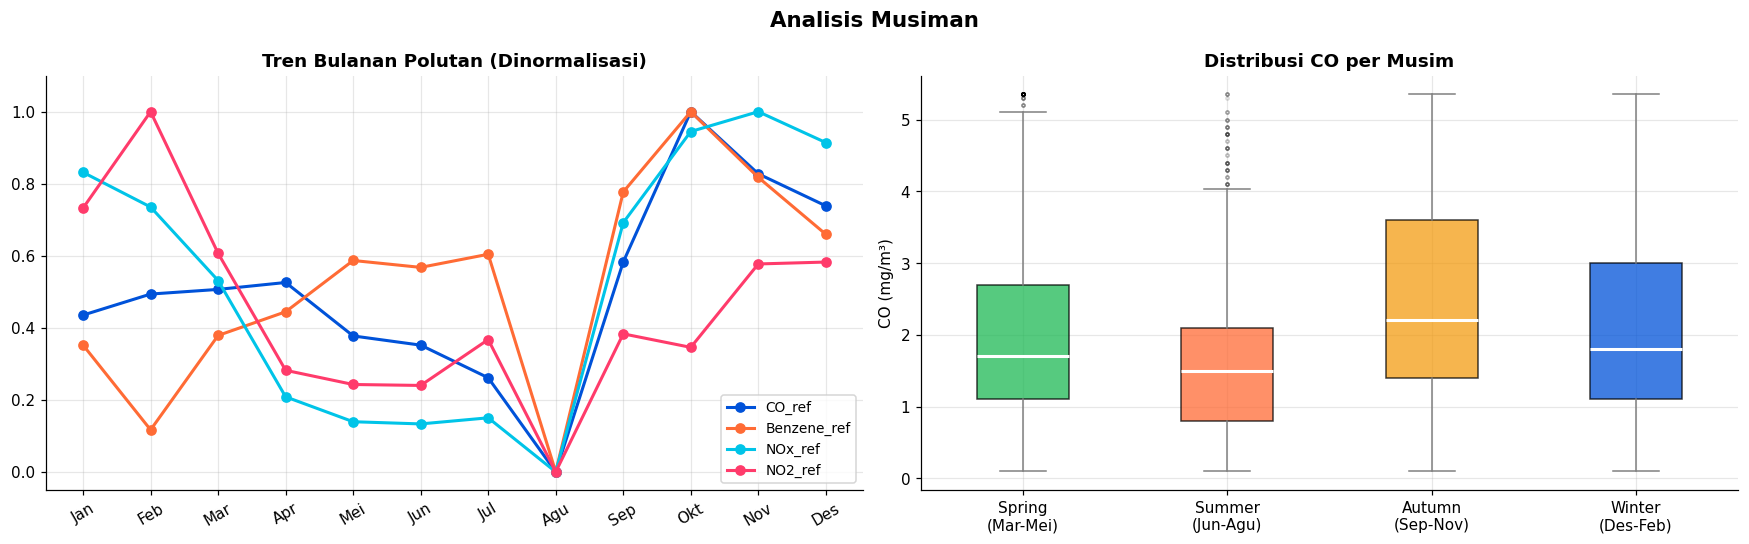

In [18]:
month_names = ['Jan','Feb','Mar','Apr','Mei','Jun',
               'Jul','Agu','Sep','Okt','Nov','Des']

monthly_avg = df.groupby('month')[pollutants].mean()
monthly_avg.index = [month_names[m-1] for m in monthly_avg.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Line chart per bulan
for col, c in zip(pollutants, [BLUE, ORANGE, CYAN, RED]):
    # Normalize ke 0-1 untuk perbandingan tren
    normalized = (monthly_avg[col] - monthly_avg[col].min()) / \
                 (monthly_avg[col].max() - monthly_avg[col].min())
    axes[0].plot(monthly_avg.index, normalized, marker='o', linewidth=2,
                 color=c, label=col, markersize=6)

axes[0].set_title('Tren Bulanan Polutan (Dinormalisasi)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.1)
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Boxplot CO per musim
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_label = {'Spring': 'Spring\n(Mar-Mei)', 'Summer': 'Summer\n(Jun-Agu)',
                'Autumn': 'Autumn\n(Sep-Nov)', 'Winter': 'Winter\n(Des-Feb)'}
df['season_label'] = df['season'].map(season_label)
order_labels = [season_label[s] for s in season_order if s in df['season'].unique()]

season_colors = {'Spring\n(Mar-Mei)': GREEN, 'Summer\n(Jun-Agu)': ORANGE,
                 'Autumn\n(Sep-Nov)': '#F39C12', 'Winter\n(Des-Feb)': BLUE}

groups = [df[df['season_label']==s]['CO_ref'].dropna() for s in order_labels]
bp = axes[1].boxplot(groups, labels=order_labels, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2),
                     whiskerprops=dict(color='gray'),
                     capprops=dict(color='gray'),
                     flierprops=dict(marker='o', alpha=0.15, markersize=2))
for patch, lbl in zip(bp['boxes'], order_labels):
    patch.set_facecolor(season_colors.get(lbl, BLUE))
    patch.set_alpha(0.75)

axes[1].set_title('Distribusi CO per Musim', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('CO (mg/m³)', fontsize=10)

plt.suptitle('Analisis Musiman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Heatmap Korelasi

Polutan mana yang paling berkaitan satu sama lain?

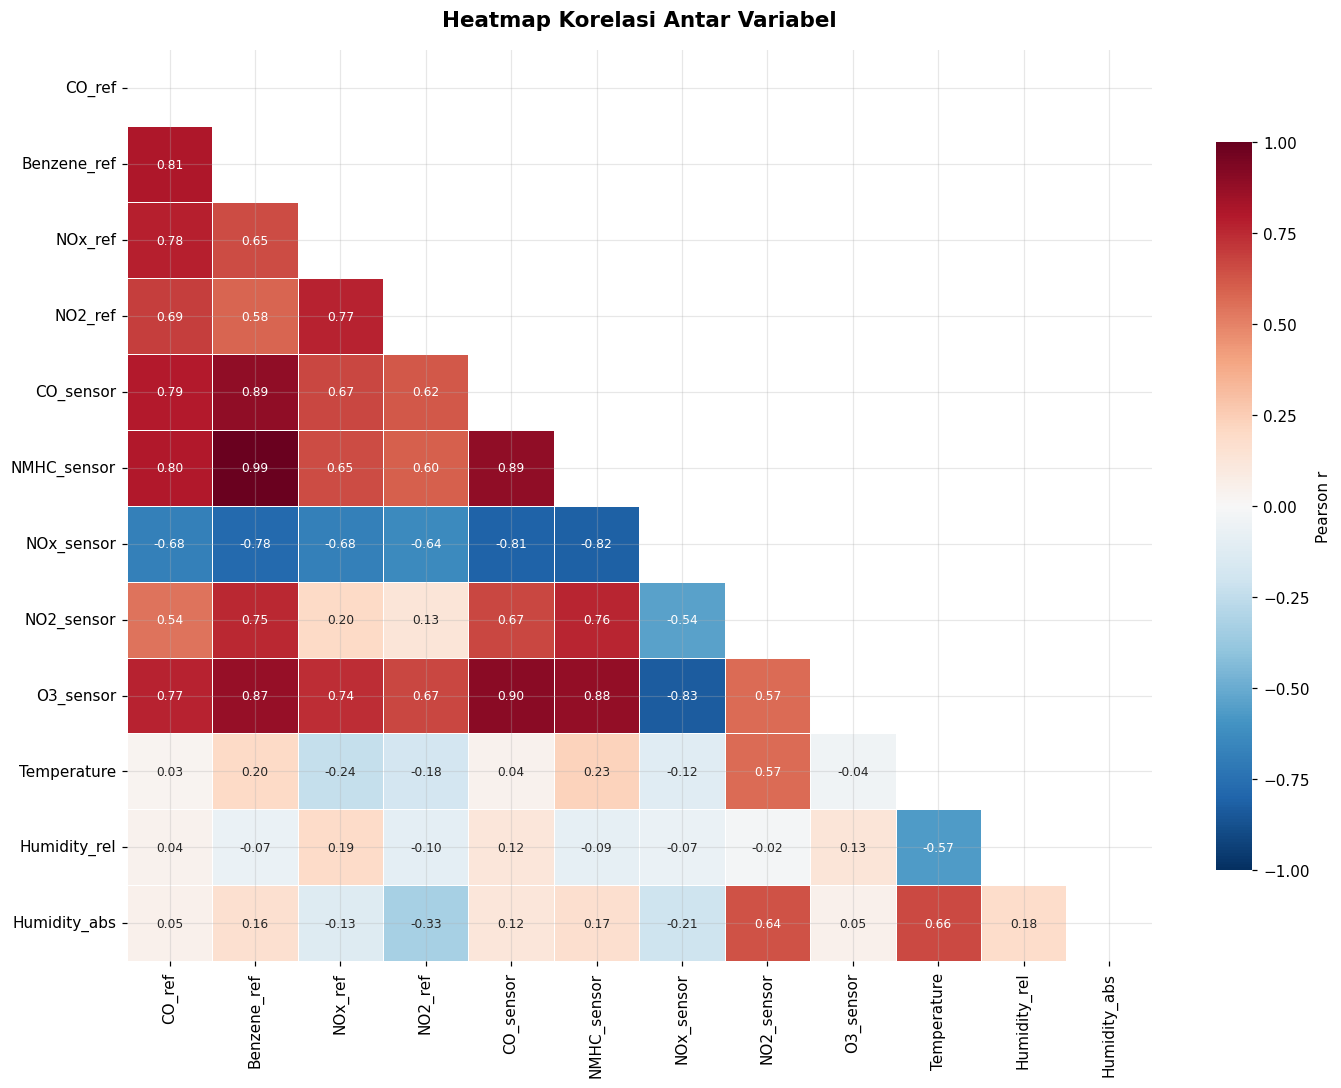


🔴 Top 5 korelasi NEGATIF:
NOx_sensor   O3_sensor    -0.83
NMHC_sensor  NOx_sensor   -0.82
CO_sensor    NOx_sensor   -0.81
Benzene_ref  NOx_sensor   -0.78
NOx_ref      NOx_sensor   -0.68

🔵 Top 5 korelasi POSITIF:
Benzene_ref  NMHC_sensor   0.99
CO_sensor    O3_sensor     0.90
Benzene_ref  CO_sensor     0.89
CO_sensor    NMHC_sensor   0.89
NMHC_sensor  O3_sensor     0.88


In [19]:
num_cols = pollutants + sensors + weather_cols
corr = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))  # sembunyikan segitiga atas (duplikat)

sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

# Top 5 korelasi positif dan negatif
corr_unstacked = corr.where(~mask).unstack().dropna()
corr_unstacked = corr_unstacked[corr_unstacked != 1.0].sort_values()

print('\n🔴 Top 5 korelasi NEGATIF:')
print(corr_unstacked.head(5).to_string())
print('\n🔵 Top 5 korelasi POSITIF:')
print(corr_unstacked.tail(5).iloc[::-1].to_string())

## 9. Scatter Plot: CO vs Benzene

CO dan Benzene keduanya berasal dari pembakaran bahan bakar kendaraan — seharusnya berkorelasi tinggi.

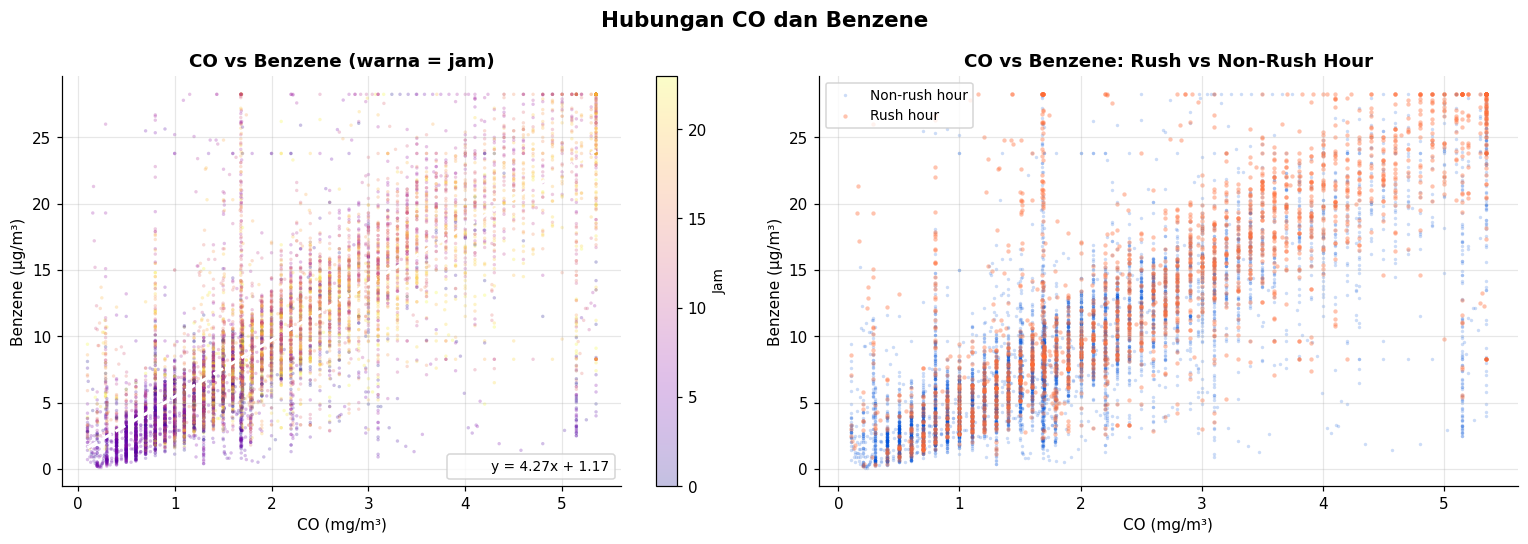


💡 Korelasi Pearson CO vs Benzene: r = 0.8061
   → Keduanya sama-sama dihasilkan pembakaran bahan bakar kendaraan


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter CO vs Benzene, warna = jam
sc = axes[0].scatter(
    df['CO_ref'], df['Benzene_ref'],
    c=df['hour'], cmap='plasma',
    alpha=0.25, s=5, linewidths=0
)
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('Jam', fontsize=9)
# Regression line
from numpy.polynomial.polynomial import polyfit
x_clean = df[['CO_ref','Benzene_ref']].dropna()
m, b = np.polyfit(x_clean['CO_ref'], x_clean['Benzene_ref'], 1)
x_range = np.linspace(x_clean['CO_ref'].min(), x_clean['CO_ref'].max(), 100)
axes[0].plot(x_range, m * x_range + b, color='white', linewidth=2,
             linestyle='--', label=f'y = {m:.2f}x + {b:.2f}')
axes[0].legend(fontsize=9)
axes[0].set_xlabel('CO (mg/m³)', fontsize=10)
axes[0].set_ylabel('Benzene (µg/m³)', fontsize=10)
axes[0].set_title('CO vs Benzene (warna = jam)', fontsize=12, fontweight='bold')

# Plot 2: Scatter CO vs Benzene, warna = rush hour
rush_mask = df['is_rush_hour'] == 1
axes[1].scatter(df.loc[~rush_mask, 'CO_ref'], df.loc[~rush_mask, 'Benzene_ref'],
                color=BLUE, alpha=0.2, s=5, label='Non-rush hour', linewidths=0)
axes[1].scatter(df.loc[rush_mask, 'CO_ref'], df.loc[rush_mask, 'Benzene_ref'],
                color=ORANGE, alpha=0.4, s=8, label='Rush hour', linewidths=0)
axes[1].set_xlabel('CO (mg/m³)', fontsize=10)
axes[1].set_ylabel('Benzene (µg/m³)', fontsize=10)
axes[1].set_title('CO vs Benzene: Rush vs Non-Rush Hour', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Hubungan CO dan Benzene', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

r = x_clean['CO_ref'].corr(x_clean['Benzene_ref'])
print(f'\n💡 Korelasi Pearson CO vs Benzene: r = {r:.4f}')
print(f'   → Keduanya sama-sama dihasilkan pembakaran bahan bakar kendaraan')

## 10. Sensor vs Referensi: Seberapa Akurat?

Dataset ini unik — punya **sensor murah** (PT08.Sx) dan **alat ukur referensi** yang mahal.  
Kita bisa mengukur seberapa akurat sensor murahnya.

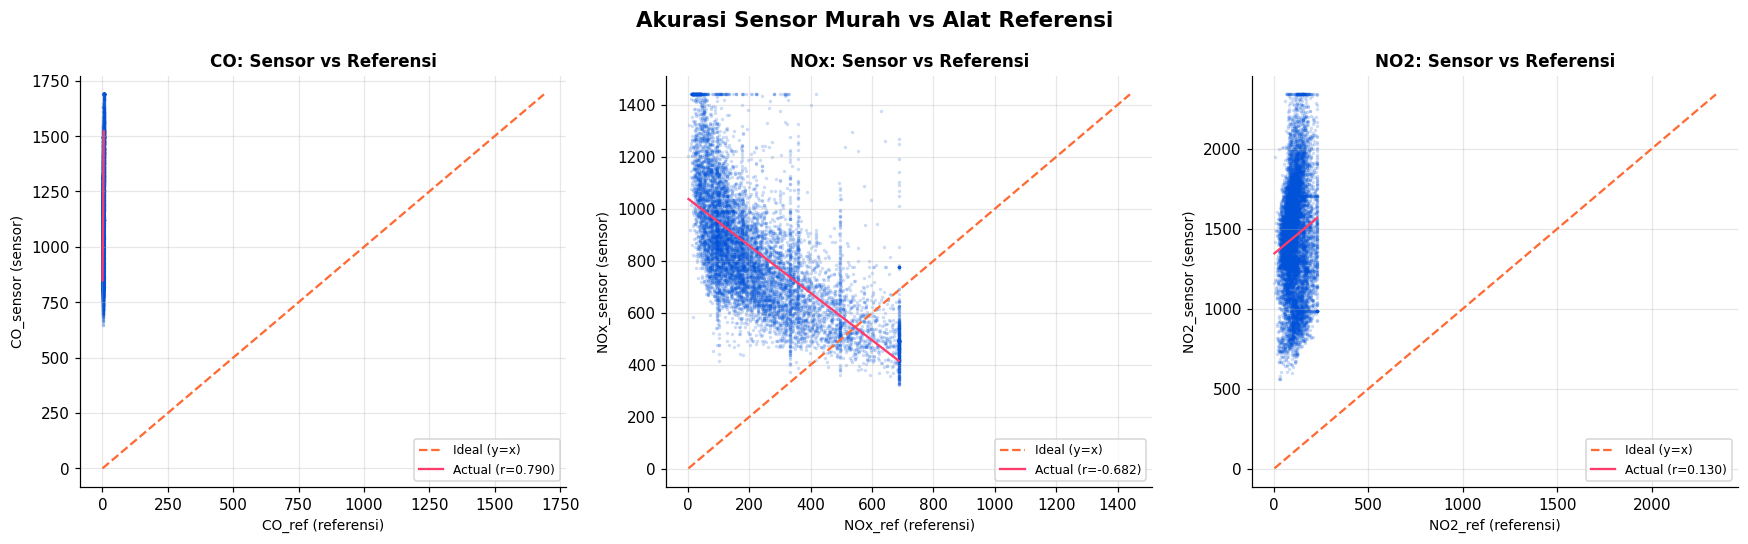


📊 Korelasi Sensor vs Referensi:
  CO    : r = 0.7895  — 🟡 Cukup akurat
  NOx   : r = -0.6823  — 🔴 Kurang akurat (perlu kalibrasi)
  NO2   : r = 0.1300  — 🔴 Kurang akurat (perlu kalibrasi)


In [21]:
# Pasangan sensor vs referensi
pairs = [
    ('CO_ref',  'CO_sensor',  'CO'),
    ('NOx_ref', 'NOx_sensor', 'NOx'),
    ('NO2_ref', 'NO2_sensor', 'NO2'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (ref_col, sen_col, name) in zip(axes, pairs):
    clean = df[[ref_col, sen_col]].dropna()
    r = clean[ref_col].corr(clean[sen_col])

    ax.scatter(clean[ref_col], clean[sen_col],
               alpha=0.2, s=5, color=BLUE, linewidths=0)

    # Garis ideal (y=x)
    min_v = min(clean[ref_col].min(), clean[sen_col].min())
    max_v = max(clean[ref_col].max(), clean[sen_col].max())
    ax.plot([min_v, max_v], [min_v, max_v],
            color=ORANGE, linewidth=1.5, linestyle='--', label='Ideal (y=x)')

    # Regression line
    m2, b2 = np.polyfit(clean[ref_col], clean[sen_col], 1)
    x_r = np.linspace(clean[ref_col].min(), clean[ref_col].max(), 100)
    ax.plot(x_r, m2 * x_r + b2, color=RED, linewidth=1.5,
            label=f'Actual (r={r:.3f})')

    ax.set_xlabel(f'{ref_col} (referensi)', fontsize=9)
    ax.set_ylabel(f'{sen_col} (sensor)', fontsize=9)
    ax.set_title(f'{name}: Sensor vs Referensi', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Akurasi Sensor Murah vs Alat Referensi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Korelasi Sensor vs Referensi:')
for ref_col, sen_col, name in pairs:
    clean = df[[ref_col, sen_col]].dropna()
    r = clean[ref_col].corr(clean[sen_col])
    print(f'  {name:<6}: r = {r:.4f}  — ', end='')
    if r > 0.9:   print('✅ Sangat akurat')
    elif r > 0.7: print('🟡 Cukup akurat')
    else:         print('🔴 Kurang akurat (perlu kalibrasi)')

## 11. Heatmap Jam × Hari: Peta Polusi Mingguan

Visualisasi ini menggabungkan dimensi jam dan hari dalam satu gambar.

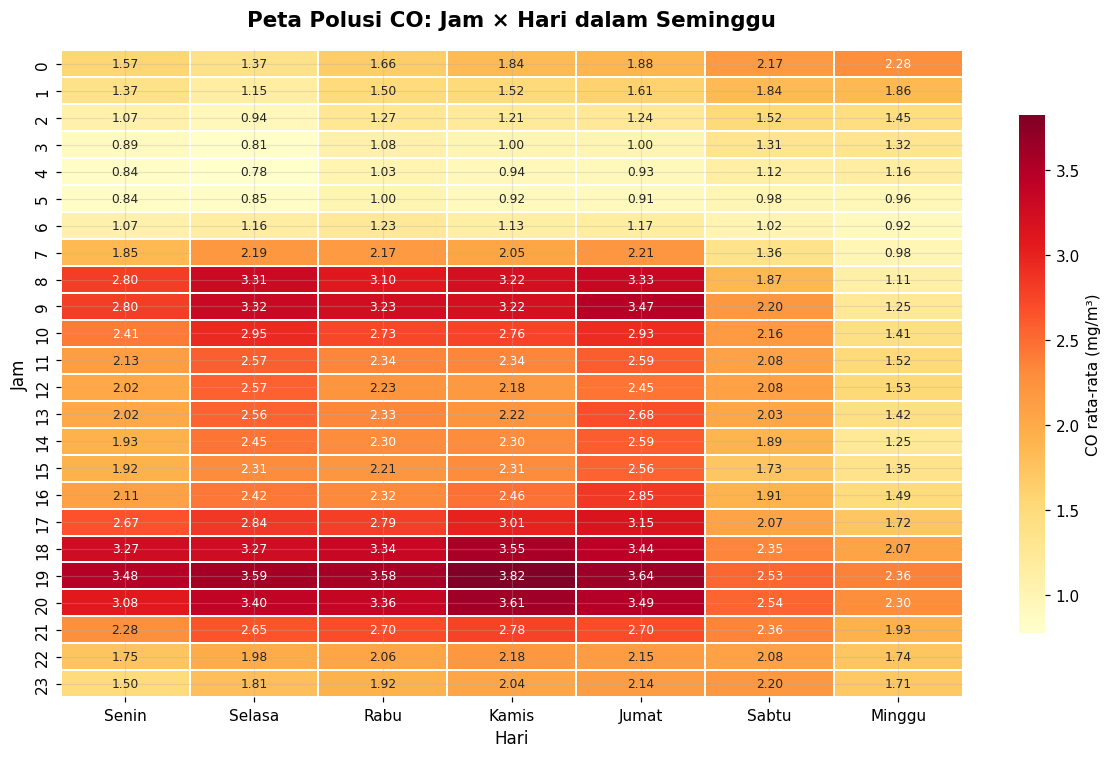


⚠️  Paling berpolusi: jam 19:00 hari Kamis → CO rata-rata 3.823 mg/m³


In [22]:
pivot = df.pivot_table(values='CO_ref', index='hour', columns='dayofweek', aggfunc='mean')
pivot.columns = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    pivot, ax=ax, cmap='YlOrRd',
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'CO rata-rata (mg/m³)', 'shrink': 0.8}
)
ax.set_title('Peta Polusi CO: Jam × Hari dalam Seminggu',
             fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Hari', fontsize=11)
ax.set_ylabel('Jam', fontsize=11)
plt.tight_layout()
plt.show()

# Temukan jam + hari paling berpolusi
max_idx = pivot.stack().idxmax()
max_val = pivot.stack().max()
print(f'\n⚠️  Paling berpolusi: jam {max_idx[0]}:00 hari {max_idx[1]} → CO rata-rata {max_val:.3f} mg/m³')

## 12. Ringkasan Temuan EDA

---

In [23]:
print('=' * 65)
print('📋 RINGKASAN TEMUAN EDA — UCI AIR QUALITY DATASET')
print('=' * 65)

rush_avg    = df[df['is_rush_hour']==1]['CO_ref'].mean()
non_rush_avg= df[df['is_rush_hour']==0]['CO_ref'].mean()
pct_diff    = (rush_avg - non_rush_avg) / non_rush_avg * 100

weekday_avg = df[df['is_weekend']==0]['CO_ref'].mean()
weekend_avg = df[df['is_weekend']==1]['CO_ref'].mean()

peak_hour   = df.groupby('hour')['CO_ref'].mean().idxmax()
best_hour   = df.groupby('hour')['CO_ref'].mean().idxmin()

print(f'''
1. DISTRIBUSI
   • Semua polutan berdistribusi right-skewed (ada spike ekstrem sesekali)
   • Ini normal untuk data kualitas udara perkotaan

2. RUSH HOUR EFFECT
   • Jam paling berpolusi (CO): {peak_hour:02d}:00
   • Jam paling bersih        : {best_hour:02d}:00 (dini hari)
   • CO di rush hour lebih tinggi {pct_diff:.1f}% vs non-rush hour

3. WEEKDAY vs WEEKEND
   • CO hari kerja  : {weekday_avg:.3f} mg/m³
   • CO weekend     : {weekend_avg:.3f} mg/m³
   • Weekend lebih bersih karena lalu lintas berkurang

4. KORELASI
   • CO & Benzene sangat berkorelasi → sama-sama dari emisi kendaraan
   • NOx berkorelasi dengan NO2 → NOx adalah prekursor NO2
   • Suhu berkorelasi NEGATIF dengan beberapa polutan
     (udara panas = lebih banyak dispersi polutan)

5. AKURASI SENSOR
   • Sensor memiliki korelasi tinggi dengan referensi untuk CO dan NOx
   • Namun ada drift sensor → tidak bisa menggantikan alat ukur referensi
''')
print('\n➡️  Lanjut ke Notebook 3: Machine Learning (Regresi & Clustering)')

📋 RINGKASAN TEMUAN EDA — UCI AIR QUALITY DATASET

1. DISTRIBUSI
   • Semua polutan berdistribusi right-skewed (ada spike ekstrem sesekali)
   • Ini normal untuk data kualitas udara perkotaan

2. RUSH HOUR EFFECT
   • Jam paling berpolusi (CO): 19:00
   • Jam paling bersih        : 05:00 (dini hari)
   • CO di rush hour lebih tinggi 44.9% vs non-rush hour

3. WEEKDAY vs WEEKEND
   • CO hari kerja  : 2.218 mg/m³
   • CO weekend     : 1.719 mg/m³
   • Weekend lebih bersih karena lalu lintas berkurang

4. KORELASI
   • CO & Benzene sangat berkorelasi → sama-sama dari emisi kendaraan
   • NOx berkorelasi dengan NO2 → NOx adalah prekursor NO2
   • Suhu berkorelasi NEGATIF dengan beberapa polutan
     (udara panas = lebih banyak dispersi polutan)

5. AKURASI SENSOR
   • Sensor memiliki korelasi tinggi dengan referensi untuk CO dan NOx
   • Namun ada drift sensor → tidak bisa menggantikan alat ukur referensi


➡️  Lanjut ke Notebook 3: Machine Learning (Regresi & Clustering)


---
# 🤖 Part 3: Machine Learning
> Lanjutan dari Part 1 & 2 — pastikan semua cell di atas sudah dijalankan,
> dan file `air_quality_cleaned.csv` sudah tersimpan di sesi Colab.

---
# 🔵 PART A: Regresi — Prediksi Kadar CO

## 1. Import & Load Data

In [24]:
# Install XGBoost (sudah tersedia di Colab, tapi pastikan versi terbaru)
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# XGBoost
from xgboost import XGBRegressor

# Style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})
BLUE   = '#0052D9'
ORANGE = '#FF6B35'
GREEN  = '#1DB954'
RED    = '#FF3B6B'
CYAN   = '#00C4E8'

# Load data
df = pd.read_csv('air_quality_cleaned.csv', index_col='DateTime', parse_dates=True)
print(f'✅ Data dimuat: {df.shape[0]} baris × {df.shape[1]} kolom')
df.head(3)

✅ Data dimuat: 9357 baris × 20 kolom


,CO_ref,CO_sensor,Benzene_ref,NMHC_sensor,NOx_ref,NOx_sensor,NO2_ref,NO2_sensor,O3_sensor,Temperature,Humidity_rel,Humidity_abs,hour,day,month,dayofweek,is_weekend,season,is_rush_hour,time_of_day
DateTime,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.60,1360.00,11.90,1046.00,166.00,1056.00,113.00,1692.00,1268.00,13.60,48.90,0.76,18,10,3,2,0,Spring,1,Sore
2004-03-10 19:00:00,2.00,1292.00,9.40,955.00,103.00,1174.00,92.00,1559.00,972.00,13.30,47.70,0.73,19,10,3,2,0,Spring,1,Sore
2004-03-10 20:00:00,2.20,1402.00,9.00,939.00,131.00,1140.00,114.00,1555.00,1074.00,11.90,54.00,0.75,20,10,3,2,0,Spring,0,Sore


## 2. Persiapan Data

**Target (y)**: `CO_ref` — kadar CO dari alat referensi (yang ingin diprediksi)

**Fitur (X)**: sensor readings + cuaca + fitur waktu

> 💡 **Logika**: Kita punya sensor murah (CO_sensor, NOx_sensor, dll.) + data cuaca.
> Bisakah kita memprediksi kadar CO referensi yang akurat dari data tersebut?

In [25]:
# Pilih fitur dan target
feature_cols = [
    # Sensor readings (input murah)
    'CO_sensor', 'NMHC_sensor', 'NOx_sensor', 'NO2_sensor', 'O3_sensor',
    # Data cuaca
    'Temperature', 'Humidity_rel', 'Humidity_abs',
    # Fitur waktu
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_rush_hour'
]
target_col = 'CO_ref'

# Drop baris yang masih ada NaN
df_ml = df[feature_cols + [target_col]].dropna()
print(f'Data setelah dropna: {df_ml.shape[0]} baris')

X = df_ml[feature_cols]
y = df_ml[target_col]

# Train-test split (80:20, tidak di-shuffle karena time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scaling (untuk Linear Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\n📊 Pembagian data:')
print(f'  Train : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  Fitur : {len(feature_cols)} kolom')
print(f'  Target: {target_col} (rata-rata = {y.mean():.3f} mg/m³)')

Data setelah dropna: 9357 baris

📊 Pembagian data:
  Train : 7485 baris (80%)
  Test  : 1872 baris (20%)
  Fitur : 13 kolom
  Target: CO_ref (rata-rata = 2.075 mg/m³)


In [26]:
# Fungsi helper untuk evaluasi model
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n📊 {name}')
    print(f'  MAE  : {mae:.4f} mg/m³')
    print(f'  RMSE : {rmse:.4f} mg/m³')
    print(f'  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)')
    return {'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)}

results = []  # tampung hasil semua model
print('✅ Helper function siap')

✅ Helper function siap


## 3. Model 1: Linear Regression (Baseline)

In [27]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

res_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)
results.append(res_lr)

# Koefisien fitur
coef_df = pd.DataFrame({
    'Fitur': feature_cols,
    'Koefisien': lr.coef_
}).sort_values('Koefisien', key=abs, ascending=False)

print('\n🔑 Top 5 fitur paling berpengaruh (Linear Regression):')
print(coef_df.head(5).to_string(index=False))


📊 Linear Regression
  MAE  : 0.4415 mg/m³
  RMSE : 0.6623 mg/m³
  R²   : 0.7390  (73.9% variance explained)

🔑 Top 5 fitur paling berpengaruh (Linear Regression):
       Fitur  Koefisien
 NMHC_sensor       0.56
   CO_sensor       0.47
       month       0.13
   O3_sensor       0.12
Humidity_abs      -0.09


## 4. Model 2: Random Forest

In [28]:
print('⏳ Melatih Random Forest (mungkin butuh 1-2 menit)...')

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)  # RF tidak butuh scaling
y_pred_rf = rf.predict(X_test)

res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)
results.append(res_rf)

⏳ Melatih Random Forest (mungkin butuh 1-2 menit)...

📊 Random Forest
  MAE  : 0.4388 mg/m³
  RMSE : 0.6557 mg/m³
  R²   : 0.7442  (74.4% variance explained)


## 5. Model 3: XGBoost

In [29]:
print('⏳ Melatih XGBoost...')

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)
results.append(res_xgb)

⏳ Melatih XGBoost...

📊 XGBoost
  MAE  : 0.4473 mg/m³
  RMSE : 0.6744 mg/m³
  R²   : 0.7294  (72.9% variance explained)


## 6. Perbandingan & Evaluasi Model

📊 PERBANDINGAN SEMUA MODEL


,MAE,RMSE,R²
Model,,,
Linear Regression,0.44,0.66,0.74
Random Forest,0.44,0.66,0.74
XGBoost,0.45,0.67,0.73



🏆 Model terbaik: Random Forest (R² = 0.7442)


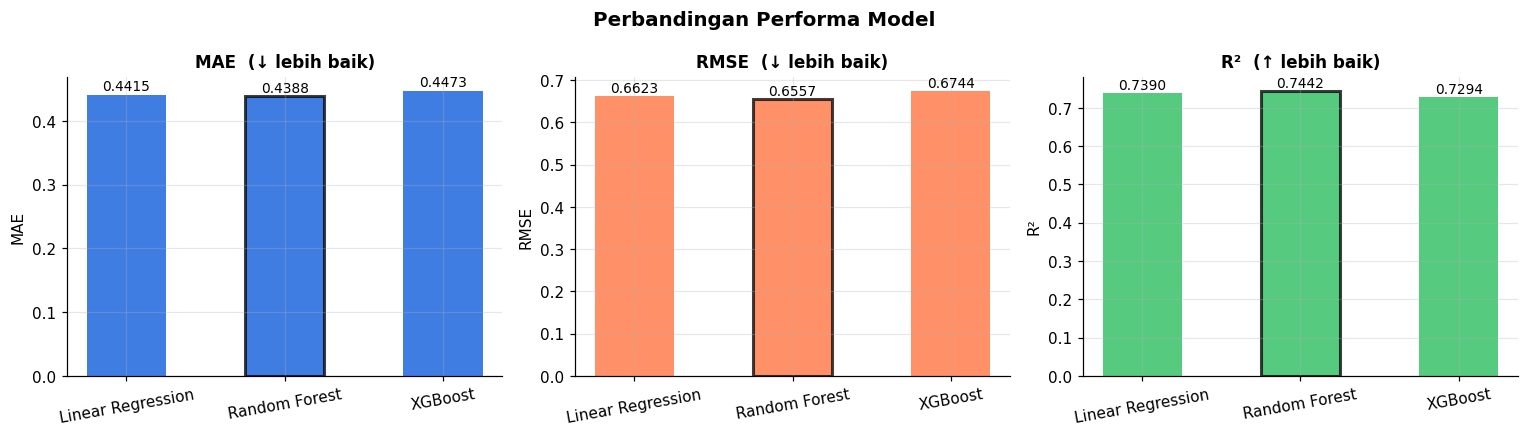

In [30]:
results_df = pd.DataFrame(results).set_index('Model')

print('=' * 55)
print('📊 PERBANDINGAN SEMUA MODEL')
print('=' * 55)
display(results_df)

best_model = results_df['R²'].idxmax()
print(f'\n🏆 Model terbaik: {best_model} (R² = {results_df.loc[best_model, "R²"]})')

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'R²']
colors  = [BLUE, ORANGE, GREEN]
better  = ['↓ lebih baik', '↓ lebih baik', '↑ lebih baik']

for ax, metric, c, b in zip(axes, metrics, colors, better):
    bars = ax.bar(results_df.index, results_df[metric], color=c, alpha=0.75, width=0.5)
    ax.set_title(f'{metric}  ({b})', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    # Highlight bar terbaik
    best_idx = results_df[metric].idxmin() if metric != 'R²' else results_df[metric].idxmax()
    best_pos = list(results_df.index).index(best_idx)
    bars[best_pos].set_edgecolor('black')
    bars[best_pos].set_linewidth(2)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Perbandingan Performa Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance

Fitur mana yang paling membantu model dalam memprediksi CO?

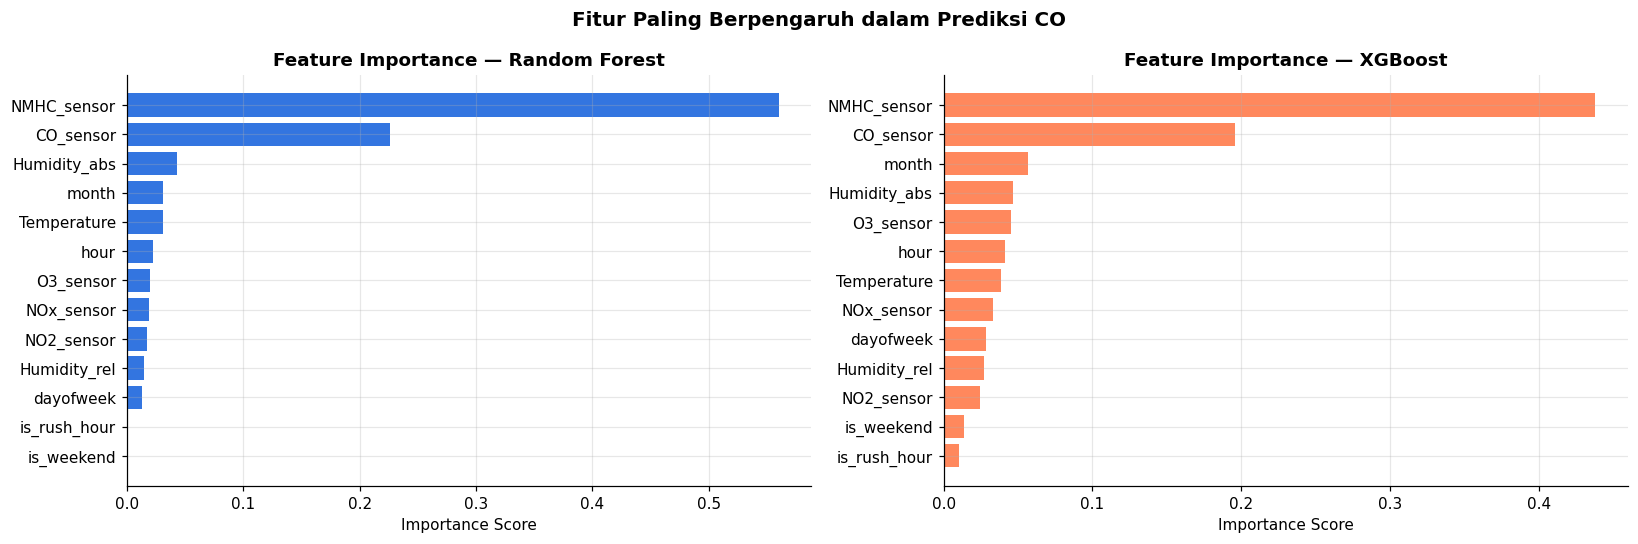


🔑 Top 3 fitur paling penting (XGBoost):
  NMHC_sensor          → 0.4379
  CO_sensor            → 0.1955
  month                → 0.0566


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, model, name, c in [
    (axes[0], rf,  'Random Forest', BLUE),
    (axes[1], xgb, 'XGBoost',       ORANGE)
]:
    imp_df = pd.DataFrame({
        'Fitur': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)

    ax.barh(imp_df['Fitur'], imp_df['Importance'], color=c, alpha=0.8)
    ax.set_title(f'Feature Importance — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Fitur Paling Berpengaruh dalam Prediksi CO', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 3 fitur XGBoost
top3 = pd.DataFrame({'Fitur': feature_cols, 'Importance': xgb.feature_importances_})\
         .sort_values('Importance', ascending=False).head(3)
print('\n🔑 Top 3 fitur paling penting (XGBoost):')
for _, row in top3.iterrows():
    print(f'  {row["Fitur"]:<20} → {row["Importance"]:.4f}')

## 8. Actual vs Predicted & Residual Plot

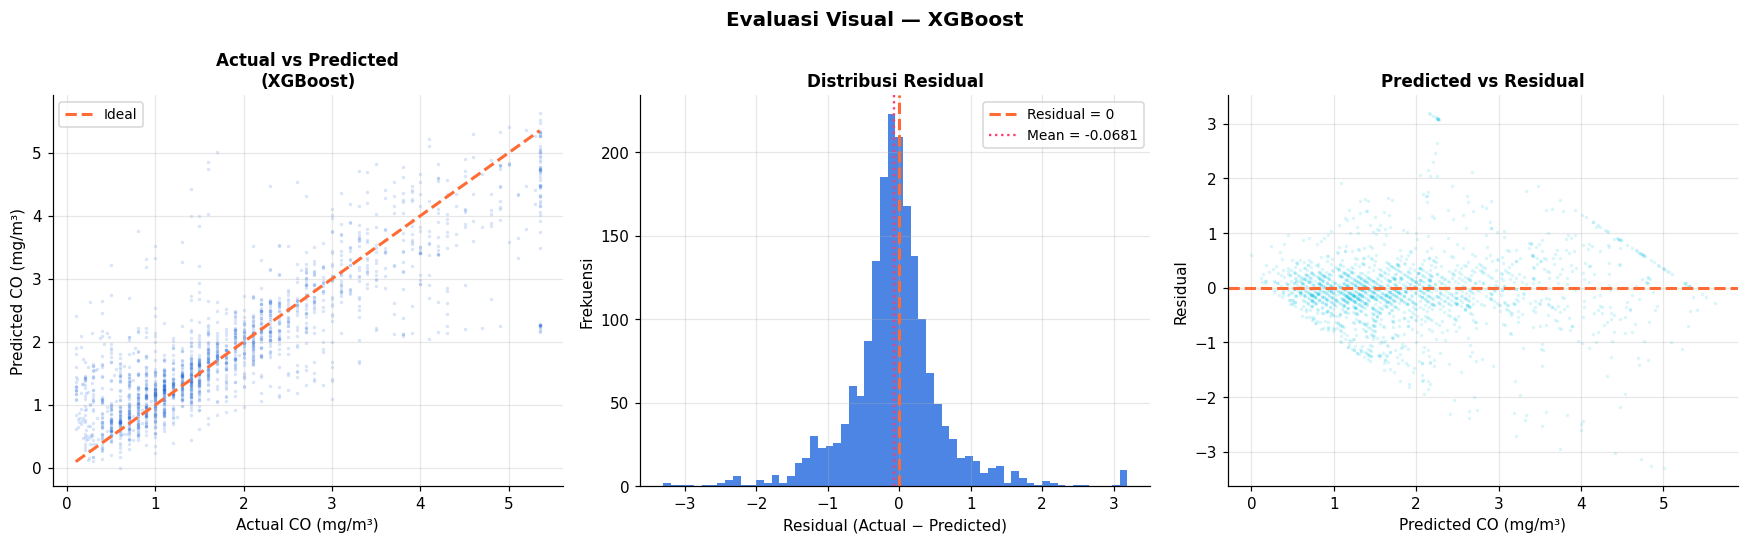

💡 Interpretasi Residual:
  Mean residual    : -0.0681  (semakin dekat 0 semakin baik)
  Std residual     : 0.6710
  % prediksi <0.5 error : 70.8%


In [32]:
# Gunakan model terbaik (biasanya XGBoost)
best_pred = y_pred_xgb
best_name = 'XGBoost'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Actual vs Predicted scatter
axes[0].scatter(y_test, best_pred, alpha=0.15, s=5, color=BLUE, linewidths=0)
min_v, max_v = y_test.min(), y_test.max()
axes[0].plot([min_v, max_v], [min_v, max_v],
             color=ORANGE, linewidth=2, linestyle='--', label='Ideal')
axes[0].set_xlabel('Actual CO (mg/m³)', fontsize=10)
axes[0].set_ylabel('Predicted CO (mg/m³)', fontsize=10)
axes[0].set_title(f'Actual vs Predicted\n({best_name})', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Plot 2: Residual distribution
residuals = y_test.values - best_pred
axes[1].hist(residuals, bins=60, color=BLUE, alpha=0.7, edgecolor='none')
axes[1].axvline(0, color=ORANGE, linewidth=2, linestyle='--', label='Residual = 0')
axes[1].axvline(residuals.mean(), color=RED, linewidth=1.5,
                linestyle=':', label=f'Mean = {residuals.mean():.4f}')
axes[1].set_xlabel('Residual (Actual − Predicted)', fontsize=10)
axes[1].set_ylabel('Frekuensi', fontsize=10)
axes[1].set_title('Distribusi Residual', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# Plot 3: Predicted vs Residual (cek heteroskedastisitas)
axes[2].scatter(best_pred, residuals, alpha=0.15, s=5, color=CYAN, linewidths=0)
axes[2].axhline(0, color=ORANGE, linewidth=2, linestyle='--')
axes[2].set_xlabel('Predicted CO (mg/m³)', fontsize=10)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].set_title('Predicted vs Residual', fontsize=11, fontweight='bold')

plt.suptitle(f'Evaluasi Visual — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'💡 Interpretasi Residual:')
print(f'  Mean residual    : {residuals.mean():.4f}  (semakin dekat 0 semakin baik)')
print(f'  Std residual     : {residuals.std():.4f}')
print(f'  % prediksi <0.5 error : {(np.abs(residuals)<0.5).mean()*100:.1f}%')

---
# 🟠 PART B: Clustering — Pengelompokan Kondisi Udara

## 9. Persiapan Data Clustering

K-Means akan mengelompokkan setiap jam menjadi beberapa kluster berdasarkan kondisi udara dan cuaca.  
Harapannya: ada kluster 'jam sibuk berpolusi', 'malam bersih', 'cuaca ekstrem', dll.

In [33]:
cluster_cols = ['CO_ref', 'Benzene_ref', 'NOx_ref', 'NO2_ref',
                'Temperature', 'Humidity_rel', 'hour']

df_cl = df[cluster_cols].dropna()
print(f'Data clustering: {df_cl.shape[0]} baris × {df_cl.shape[1]} kolom')

# Scaling wajib untuk K-Means
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df_cl)

print(f'✅ Data di-scale dengan StandardScaler')
print(f'   Mean ≈ 0, Std ≈ 1 setelah scaling')

Data clustering: 9357 baris × 7 kolom
✅ Data di-scale dengan StandardScaler
   Mean ≈ 0, Std ≈ 1 setelah scaling


## 10. Elbow Method & Silhouette Score

Cari nilai K (jumlah kluster) yang optimal.

⏳ Menghitung Elbow dan Silhouette (K=2 sampai 9)...
  K=2 → Inertia=44470, Silhouette=0.3018
  K=3 → Inertia=33779, Silhouette=0.2812
  K=4 → Inertia=29216, Silhouette=0.2657
  K=5 → Inertia=26800, Silhouette=0.2529
  K=6 → Inertia=24541, Silhouette=0.2234
  K=7 → Inertia=23008, Silhouette=0.2175
  K=8 → Inertia=21492, Silhouette=0.2139
  K=9 → Inertia=20292, Silhouette=0.2162


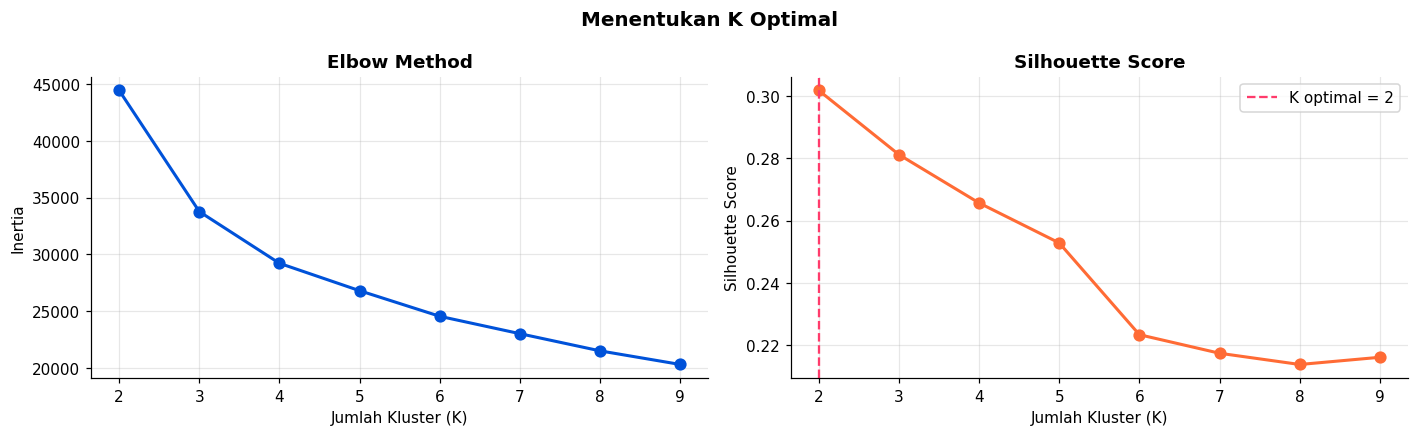


✅ K optimal berdasarkan Silhouette Score: K = 2


In [34]:
print('⏳ Menghitung Elbow dan Silhouette (K=2 sampai 9)...')

inertias   = []
sil_scores = []
K_range    = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl, labels, sample_size=2000, random_state=42))
    print(f'  K={k} → Inertia={km.inertia_:.0f}, Silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
axes[0].plot(K_range, inertias, marker='o', color=BLUE, linewidth=2, markersize=7)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))

# Silhouette
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].plot(K_range, sil_scores, marker='o', color=ORANGE, linewidth=2, markersize=7)
axes[1].axvline(best_k, color=RED, linestyle='--', linewidth=1.5,
                label=f'K optimal = {best_k}')
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend(fontsize=10)

plt.suptitle('Menentukan K Optimal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✅ K optimal berdasarkan Silhouette Score: K = {best_k}')

## 11. K-Means Clustering

In [35]:
# Jalankan K-Means dengan K optimal
K_OPTIMAL = best_k   # ganti manual jika ingin coba K lain, misal K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_cl['Cluster'] = km_final.fit_predict(X_cl)

print(f'✅ K-Means selesai dengan K = {K_OPTIMAL}')
print(f'\n📊 Jumlah data per kluster:')
print(df_cl['Cluster'].value_counts().sort_index().to_string())

# Profil tiap kluster (rata-rata fitur)
print('\n📋 Profil rata-rata tiap kluster:')
profile = df_cl.groupby('Cluster')[cluster_cols].mean().round(3)
display(profile)

✅ K-Means selesai dengan K = 2

📊 Jumlah data per kluster:
Cluster
0    3112
1    6245

📋 Profil rata-rata tiap kluster:


,CO_ref,Benzene_ref,NOx_ref,NO2_ref,Temperature,Humidity_rel,hour
Cluster,,,,,,,
0,3.53,17.11,421.90,153.14,17.50,50.02,14.49
1,1.35,6.49,139.07,87.03,18.63,48.60,10.01


## 12. Visualisasi Cluster (PCA)

Karena data punya banyak dimensi, kita kompres ke 2D dengan PCA untuk bisa divisualisasikan.

PCA variance explained: PC1=47.4%, PC2=25.8%
Total: 73.1% informasi terjaga


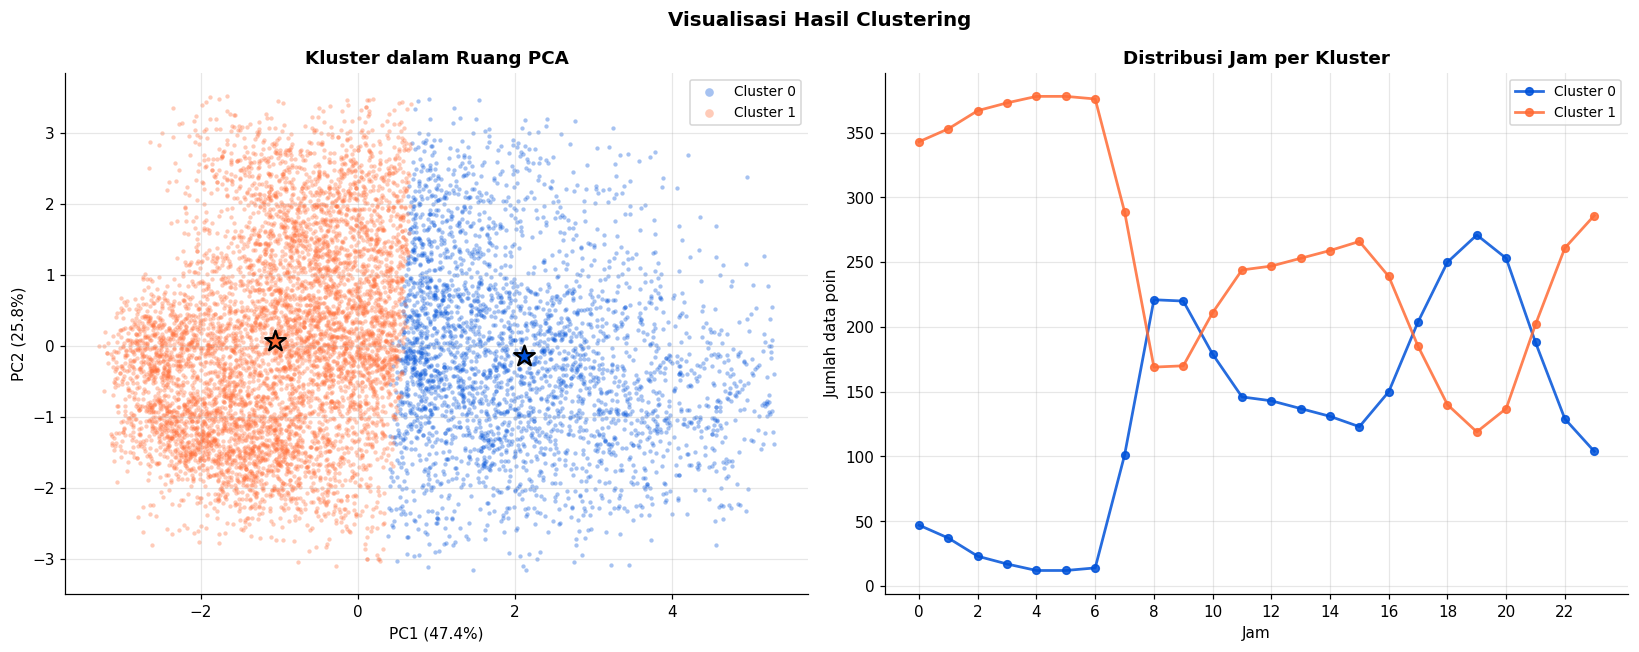

In [36]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl)

var_explained = pca.explained_variance_ratio_ * 100
print(f'PCA variance explained: PC1={var_explained[0]:.1f}%, PC2={var_explained[1]:.1f}%')
print(f'Total: {sum(var_explained):.1f}% informasi terjaga')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = [BLUE, ORANGE, GREEN, RED, CYAN, '#9B59B6', '#F39C12', '#E74C3C']

# Plot 1: PCA scatter by cluster
for c in range(K_OPTIMAL):
    mask = df_cl['Cluster'] == c
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=8, alpha=0.35, color=palette[c],
        label=f'Cluster {c}', linewidths=0
    )
    # Centroid
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    axes[0].scatter(cx, cy, s=200, color=palette[c],
                    edgecolors='black', linewidths=1.5, zorder=5, marker='*')

axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=10)
axes[0].set_title('Kluster dalam Ruang PCA', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, markerscale=2)

# Plot 2: Distribusi jam per kluster
for c in range(K_OPTIMAL):
    mask = df_cl['Cluster'] == c
    axes[1].plot(
        df_cl[mask].groupby('hour').size(),
        marker='o', markersize=5, linewidth=1.8,
        color=palette[c], label=f'Cluster {c}', alpha=0.85
    )

axes[1].set_xlabel('Jam', fontsize=10)
axes[1].set_ylabel('Jumlah data poin', fontsize=10)
axes[1].set_title('Distribusi Jam per Kluster', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=9)

plt.suptitle('Visualisasi Hasil Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Interpretasi & Labeling Kluster

Berikan label bermakna berdasarkan profil rata-rata tiap kluster.

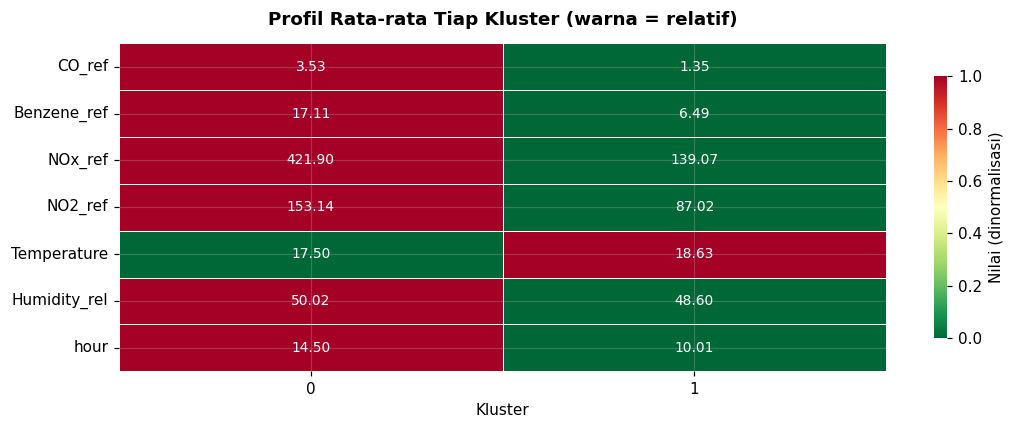


💡 Panduan interpretasi kluster:
   CO tinggi + jam 7-9 atau 17-19 → 🚗 Rush Hour Berpolusi
   CO rendah + jam 0-5            → 🌙 Malam Bersih
   Suhu tinggi + kelembapan rendah → ☀️  Siang Kering
   Kelembapan tinggi + CO sedang  → 🌧️  Kondisi Lembap

📋 Profil kluster (nilai asli):


,CO_ref,Benzene_ref,NOx_ref,NO2_ref,Temperature,Humidity_rel,hour
Cluster,,,,,,,
0,3.53,17.11,421.90,153.14,17.50,50.02,14.49
1,1.35,6.49,139.07,87.03,18.63,48.60,10.01


In [37]:
# Visualisasi heatmap profil kluster
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    profile_norm.T, ax=ax,
    cmap='RdYlGn_r', annot=profile.T.round(2),
    fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Nilai (dinormalisasi)', 'shrink': 0.8}
)
ax.set_title('Profil Rata-rata Tiap Kluster (warna = relatif)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Kluster')
plt.tight_layout()
plt.show()

# Labeling otomatis berdasarkan CO dan jam
print('\n💡 Panduan interpretasi kluster:')
print('   CO tinggi + jam 7-9 atau 17-19 → 🚗 Rush Hour Berpolusi')
print('   CO rendah + jam 0-5            → 🌙 Malam Bersih')
print('   Suhu tinggi + kelembapan rendah → ☀️  Siang Kering')
print('   Kelembapan tinggi + CO sedang  → 🌧️  Kondisi Lembap')

print('\n📋 Profil kluster (nilai asli):')
display(profile)

In [38]:
# Tambahkan label kluster ke dataframe asli
# ⚠️ Sesuaikan mapping ini setelah melihat profil di atas!
#    Contoh untuk K=4 — ganti sesuai hasil aktualmu:

label_map = {
    0: 'Kluster 0',
    1: 'Kluster 1',
    2: 'Kluster 2',
    3: 'Kluster 3',
}  # Isi ulang setelah lihat profil di cell atas

df_cl['Label'] = df_cl['Cluster'].map(label_map)

print('📊 Distribusi label:')
print(df_cl['Label'].value_counts().to_string())

# Simpan hasil clustering
df_cl.to_csv('air_quality_clustered.csv')
print('\n💾 Hasil clustering disimpan: air_quality_clustered.csv')

📊 Distribusi label:
Label
Kluster 1    6245
Kluster 0    3112

💾 Hasil clustering disimpan: air_quality_clustered.csv


## 14. Ringkasan Temuan Machine Learning

In [39]:
print('=' * 65)
print('📋 RINGKASAN — NOTEBOOK 3: MACHINE LEARNING')
print('=' * 65)

best_r2  = results_df['R²'].max()
best_mae = results_df.loc[results_df['R²'].idxmax(), 'MAE']

print(f'''
PART A — REGRESI (Target: Prediksi CO)
┌─────────────────────────────────────────────┐
  Model terbaik : {results_df['R²'].idxmax()}
  R²            : {best_r2:.4f} ({best_r2*100:.1f}% variance explained)
  MAE           : {best_mae:.4f} mg/m³

  Artinya: model bisa memprediksi kadar CO
  dengan error rata-rata ±{best_mae:.3f} mg/m³
└─────────────────────────────────────────────┘

PART B — CLUSTERING (K-Means)
┌─────────────────────────────────────────────┐
  K optimal     : {K_OPTIMAL} kluster
  Kluster ditemukan berdasarkan:
  → Kombinasi level polutan (CO, Benzene, NOx)
  → Kondisi cuaca (suhu, kelembapan)
  → Pola waktu (jam dalam sehari)
└─────────────────────────────────────────────┘

OUTPUT FILE:
  ✅ air_quality_clustered.csv (data + label kluster)
''')

print('🎉 Notebook 3 selesai!')
print('\nIde pengembangan selanjutnya:')
print('  → Hyperparameter tuning dengan GridSearchCV')
print('  → Deploy model ke Streamlit / Flask')
print('  → Coba LSTM untuk prediksi time series')

📋 RINGKASAN — NOTEBOOK 3: MACHINE LEARNING

PART A — REGRESI (Target: Prediksi CO)
┌─────────────────────────────────────────────┐
  Model terbaik : Random Forest
  R²            : 0.7442 (74.4% variance explained)
  MAE           : 0.4388 mg/m³
  
  Artinya: model bisa memprediksi kadar CO
  dengan error rata-rata ±0.439 mg/m³
└─────────────────────────────────────────────┘

PART B — CLUSTERING (K-Means)
┌─────────────────────────────────────────────┐
  K optimal     : 2 kluster
  Kluster ditemukan berdasarkan:
  → Kombinasi level polutan (CO, Benzene, NOx)
  → Kondisi cuaca (suhu, kelembapan)
  → Pola waktu (jam dalam sehari)
└─────────────────────────────────────────────┘

OUTPUT FILE:
  ✅ air_quality_clustered.csv (data + label kluster)

🎉 Notebook 3 selesai!

Ide pengembangan selanjutnya:
  → Hyperparameter tuning dengan GridSearchCV
  → Deploy model ke Streamlit / Flask
  → Coba LSTM untuk prediksi time series


In [40]:
# ── Simpan model & data untuk Streamlit ──────────────────────────
import joblib

# Simpan model Random Forest
joblib.dump(rf, 'model_rf.pkl')
print('✅ model_rf.pkl tersimpan')

# Simpan cleaned data (kalau belum ada)
df.to_csv('air_quality_cleaned.csv')
print('✅ air_quality_cleaned.csv tersimpan')

# Download kedua file dari Colab ke komputer
from google.colab import files
files.download('model_rf.pkl')
files.download('air_quality_cleaned.csv')
print('📥 File siap didownload!')

✅ model_rf.pkl tersimpan
✅ air_quality_cleaned.csv tersimpan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 File siap didownload!
